In [1]:
#!pip -q install numpy pandas matplotlib scikit-learn tqdm vector
#!pip install --upgrade gdown

import sys
import importlib
import os
import urllib.request
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import glob
import gc
import pylhe



# Force-download the newest version of the helper file
!wget -q -O helpers.py https://raw.githubusercontent.com/andlessa/UnfoldingBSMttbar/main/helpers.py

# Import the module and force Python to clear cache and reload it
import helpers as hp
importlib.reload(hp)

# Global Plotting Configuration
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 12, "axes.labelsize": 14, "axes.titlesize": 14,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "lines.linewidth": 2.2, "lines.markersize": 4.5,
    "legend.frameon": False, "mathtext.fontset": "cm",
})

# Dictionaries for styling
pair_colors = {"Scalar vs VLF": "#1f77b4", "Scalar vs Zprime": "#2ca02c", "VLF vs Zprime": "#d62728"}
class_colors = {"Scalar": "#1f77b4", "VLF": "#ff7f0e", "Zprime": "#2ca02c"}
pair_latex = {"Scalar vs VLF": r"Scalar vs VLF", "Scalar vs Zprime": r"Scalar vs $Z^\prime$", "VLF vs Zprime": r"VLF vs $Z^\prime$"}
class_latex = {"Scalar": r"Scalar", "VLF": r"VLF", "Zprime": r"$Z^\prime$"}
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}
eps_styles = {
    0.0: ('-', 'D'),
    0.02: ("-.", "o"),
    0.05: ("--", "s"),
    0.10: (":", "^")
}

# Loading the computed matrix elements

In [63]:
import pandas as pd

# Path to your final CSV
csv_path = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_Cleaned.csv.gz"

# Load ONLY the first 100 rows to save RAM and time
df_head = pd.read_csv(csv_path, nrows=100)

# Show all columns so they don't get hidden with '...'
pd.set_option('display.max_columns', None)

# Display the first 5 events
display(df_head.head())

,Event,x1,x2,s_hat,dynamic_scale,alphas,mg_weight,w_gg,w_uux,w_ddx,w_ssx,w_ccx,w_bbx,ME_Born_SM_Zprime_P0_gg_ttx,ME_Born_NP_Zprime_P0_gg_ttx,ME_Born_VLF_P0_uux_ttx,ME_Finite_VLF_P0_uux_ttx,ME_Born_Scalar_P0_uux_ttx,ME_Finite_Scalar_P0_uux_ttx,ME_Born_SM_Zprime_P3_ddx_ttx,ME_Born_NP_Zprime_P3_ddx_ttx,ME_Born_Scalar_P2_gg_ttx,ME_Finite_Scalar_P2_gg_ttx,ME_Born_SM_Zprime_P2_uux_ttx,ME_Born_NP_Zprime_P2_uux_ttx,ME_Born_VLF_P2_gg_ttx,ME_Finite_VLF_P2_gg_ttx
0,0,0.051085,0.273962,2.365224e+06,225.103126,0.104218,5.527527e-07,13.862747,5.073260,2.613728,0.059012,0.034213,0.012155,12.420442,0.0,0.748708,0.000884,0.748708,0.000571,7.487117e-01,0.000003,12.420180,-0.000321,1.750594e+09,0.000003,12.420180,0.000261
1,1,0.074593,0.201953,2.545869e+06,184.560007,0.106763,5.419669e-07,19.606602,4.836127,3.186983,0.143293,0.051476,0.017810,21.297428,0.0,0.797170,0.001026,0.797170,0.000671,1.750594e+09,0.000004,21.296750,-0.000546,7.971742e-01,0.000004,21.296750,0.000444
2,2,0.028864,0.509567,2.485691e+06,213.816214,0.104860,1.188034e-07,1.124798,1.730335,0.517565,-0.039211,0.000613,0.000320,14.781906,0.0,0.761699,0.000953,0.761699,0.000621,1.750590e+09,0.000004,14.781558,-0.000374,7.617033e-01,0.000004,14.781558,0.000311
3,3,0.058799,0.246377,2.448271e+06,175.466922,0.107465,2.729135e-07,16.672884,5.080911,2.877359,0.093129,0.040532,0.013898,22.938697,0.0,0.809734,0.000995,0.809734,0.000647,1.750572e+09,0.000004,22.937888,-0.000610,8.097379e-01,0.000004,22.937888,0.000474
4,4,0.070379,0.203715,2.422997e+06,205.623012,0.105350,6.113981e-07,21.138280,5.257941,3.412141,0.155541,0.057386,0.020204,15.756895,0.0,0.770782,0.000936,0.770782,0.000607,1.750591e+09,0.000004,15.756495,-0.000409,7.707855e-01,0.000004,15.756495,0.000329


In [12]:
print(np.sqrt(2.365224e+06))

1537.9284768805082


# Computing the likelihood using MEM

In [ ]:
import os
import sys
import glob
import importlib.util
import numpy as np
import pandas as pd
import pylhe
import concurrent.futures
from tqdm.notebook import tqdm
import multiprocessing as mp

# --- LHAPDF Path Setup ---
sys.path.append("/home/vinicius/MG5/HEPTools/lhapdf6_py3/lib/python3.14/dist-packages")
import lhapdf

# ==========================================
# 1. CONFIGURATION & SETUP
# ==========================================
E_BEAM = 6500.0    
PDF_NAME = 244600  
MU_F  = 91.188     
MU_R  = 91.188    
MU_R2 = MU_R**2    

MODEL_ROOTS = {
    "VLF":    os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/UV_BSM/MatrixElements/SubProcesses"),
    "Scalar": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/SMS_1_loop/MatrixElements/SubProcesses"),
    "Zprime": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/z_prime/nlo_MatrixElements/SubProcesses")
}

MODEL_CHANNELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": ["P3_uux_ttx", "P5_ddx_ttx", "P7_gg_ttx"]
}

PDG_MAP = {"uux": 2, "ddx": 1, "ssx": 3, "ccx": 4, "bbx": 5}

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p

def init_model_card(module, subproc_path, module_label):
    """Dynamically detects and calls the correct Fortran initialization routine."""
    card_path = os.path.abspath(os.path.join(subproc_path, "..", "..", "Cards", "param_card.dat"))
    if not os.path.exists(card_path):
        raise FileNotFoundError(f"[{module_label}] Could not find parameter card at: {card_path}")
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        mod_attrs = dir(module)
        lo_init = [a for a in mod_attrs if a.endswith('initialisemodel')]
        nlo_init = [a for a in mod_attrs if 'initialise' in a and not a.endswith('initialisemodel')]
        
        if lo_init:
            getattr(module, lo_init[0])(card_path)
        elif nlo_init:
            getattr(module, nlo_init[0])(card_path)
        else:
            raise AttributeError(f"[{module_label}] No valid initialization subroutine found!")
    finally:
        os.chdir(original_cwd)

def eval_full_me(mod, subproc_path, p_fortran, alphas, scale2, nhel=-1):
    mod_attrs = dir(mod)
    nlo_eval = [a for a in mod_attrs if a.endswith('get_me')]
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        res, ret_code = getattr(mod, nlo_eval[0])(p_fortran, alphas, scale2, nhel)
        res_arr = np.array(res)
        
        if res_arr.ndim == 2:
            if res_arr.shape[1] > 3:
                born_sm, born_bsm = float(res_arr[0, 3]), float(res_arr[0, 1])
            else:
                born_sm, born_bsm = float(res_arr[0, 0]), 0.0
            return {"born_sm": born_sm, "bsm_leading": born_bsm}
            
        elif res_arr.ndim == 1 and res_arr.size == 4:
            return {"born_sm": float(res_arr[0]), "bsm_leading": float(res_arr[1])}
        else:
            res_list = np.ravel(res_arr)
            finite_val = float(res_list[0]) if len(res_list) > 0 else 0.0
            return {"born_sm": 0.0, "bsm_leading": finite_val}
    finally:
        os.chdir(original_cwd)

# ==========================================
# 3. ISOLATED WORKER PROCESS
# ==========================================
def worker_evaluate_model(model_name, channel_paths, kinematics_list):
    """Runs entirely in isolated RAM. Loads libraries and evaluates events."""
    print(f"\n[{model_name}] OS Process started. Loading & Initializing modules...")
    
    loaded_modules = {}
    for ch_name, subproc_path in channel_paths.items():
        if subproc_path not in sys.path:
            sys.path.append(subproc_path)
            
        so_files = glob.glob(os.path.join(subproc_path, f"*matrix_{model_name}*.so")) or \
                   glob.glob(os.path.join(subproc_path, "*matrix*.so"))
                   
        if not so_files:
            continue
            
        so_path = so_files[0]
        lib_name = os.path.basename(so_path).split(".")[0]
        
        # Load the Fortran library
        spec = importlib.util.spec_from_file_location(lib_name, so_path)
        mod = importlib.util.module_from_spec(spec)
        sys.modules[lib_name] = mod
        spec.loader.exec_module(mod)
        
        # INITIALIZE FORTRAN PARAMETERS using your function!
        init_model_card(mod, subproc_path, f"{model_name} | {ch_name}")
        
        loaded_modules[ch_name] = {"module": mod, "path": subproc_path}
        print(f"  [{model_name}] [✓] Initialized {ch_name}")

    print(f"[{model_name}] Evaluating {len(kinematics_list)} events...")
    results = []
    
    for idx, (P_fortran, alphas, scale_sq) in enumerate(kinematics_list):
        event_record = {"Event": idx}
        for ch_name, mod_dict in loaded_modules.items():
            try:
                me_dict = eval_full_me(mod_dict["module"], mod_dict["path"], P_fortran, alphas, scale_sq, -1)
                if model_name == "Zprime":
                    event_record[f"ME_Born_SM_{model_name}_{ch_name}"] = me_dict["born_sm"]
                    event_record[f"ME_Born_NP_{model_name}_{ch_name}"] = me_dict["bsm_leading"]
                else:
                    event_record[f"ME_Born_{model_name}_{ch_name}"] = me_dict["born_sm"]
                    event_record[f"ME_Finite_{model_name}_{ch_name}"] = me_dict["bsm_leading"]
            except Exception:
                if model_name == "Zprime":
                    event_record[f"ME_Born_SM_{model_name}_{ch_name}"] = np.nan
                    event_record[f"ME_Born_NP_{model_name}_{ch_name}"] = np.nan
                else:
                    event_record[f"ME_Born_{model_name}_{ch_name}"] = np.nan
                    event_record[f"ME_Finite_{model_name}_{ch_name}"] = np.nan
        results.append(event_record)
        
    return pd.DataFrame(results)

# ==========================================
# 4. MASTER PIPELINE ORCHESTRATOR
# ==========================================
def compute_matrix_elements(lhe_path, output_csv_path, model_path_dict):
    print(f"Processing LHE file: {lhe_path}")
    pdf = lhapdf.mkPDF(PDF_NAME) if isinstance(PDF_NAME, int) else lhapdf.mkPDF(str(PDF_NAME), 0)
    
    try:
        total_events = pylhe.read_num_events(lhe_path)
    except:
        total_events = None

    events = pylhe.read_lhe_with_attributes(lhe_path)
    base_results, kinematics_list = [], []
    
    for idx, event in enumerate(tqdm(events, total=total_events, desc="Extracting Kinematics")):
        outgoing = [p for p in event.particles if p.status == 1]
        if len(outgoing) != 2: continue
            
        tops = sorted(outgoing, key=lambda x: x.id, reverse=True)
        t, tbar = tops[0], tops[1]
        
        E_tt, pz_tt = t.e + tbar.e, t.pz + tbar.pz
        x1, x2 = (E_tt + pz_tt) / (2.0 * E_BEAM), (E_tt - pz_tt) / (2.0 * E_BEAM)
        if not (0 < x1 < 1.0 and 0 < x2 < 1.0): continue
            
        s_hat = E_tt**2 - (t.px + tbar.px)**2 - (t.py + tbar.py)**2 - pz_tt**2
        
        HT = sum(np.sqrt(p.m**2 + p.px**2 + p.py**2) for p in outgoing)
        dynamic_scale = HT / 2.0
        alphas = pdf.alphasQ(dynamic_scale)
        
        w_gg = (pdf.xfxQ(21, x1, dynamic_scale) / x1) * (pdf.xfxQ(21, x2, dynamic_scale) / x2)
        pdf_fluxes = {"w_gg": w_gg}
        for q_name, q_id in PDG_MAP.items():
            fq_1, fqbar_2 = pdf.xfxQ(q_id, x1, dynamic_scale) / x1, pdf.xfxQ(-q_id, x2, dynamic_scale) / x2
            fqbar_1, fq_2 = pdf.xfxQ(-q_id, x1, dynamic_scale) / x1, pdf.xfxQ(q_id, x2, dynamic_scale) / x2
            pdf_fluxes[f"w_{q_name}"] = (fq_1 * fqbar_2) + (fqbar_1 * fq_2)
        
        P_fortran = np.asfortranarray(invert_momenta([
            [x1 * E_BEAM, 0.0, 0.0,  x1 * E_BEAM],
            [x2 * E_BEAM, 0.0, 0.0, -x2 * E_BEAM],
            [t.e, t.px, t.py, t.pz], [tbar.e, tbar.px, tbar.py, tbar.pz]
        ]), dtype=np.float64)
        
        base_results.append({"Event": idx, "x1": x1, "x2": x2, "s_hat": s_hat, 
                             "dynamic_scale": dynamic_scale, "alphas": alphas, 
                             "mg_weight": event.eventinfo.weight, **pdf_fluxes})
        kinematics_list.append((P_fortran, alphas, dynamic_scale**2))

    df_master = pd.DataFrame(base_results)
    model_dataframes = []
    
    with concurrent.futures.ProcessPoolExecutor(max_workers=len(model_path_dict)) as executor:
        future_to_model = {
            executor.submit(worker_evaluate_model, m_name, ch_paths, kinematics_list): m_name 
            for m_name, ch_paths in model_path_dict.items()
        }
        for future in concurrent.futures.as_completed(future_to_model):
            try:
                model_dataframes.append(future.result())
            except Exception as exc:
                print(f"Process generated an exception: {exc}")

    for df_model in model_dataframes:
        df_master = pd.merge(df_master, df_model, on="Event")
    
    df_master = df_master.dropna().reset_index(drop=True)
    if output_csv_path:
        df_master.to_csv(output_csv_path, index=False, compression='infer')
        
    return df_master

# ==========================================
# 5. EXECUTION BLOCK
# ==========================================
if __name__ == '__main__':
    # Dynamically build the path dictionary (strings only!) to pass to the workers
    model_path_dict = {}
    for m_name, root_dir in MODEL_ROOTS.items():
        model_path_dict[m_name] = {ch: os.path.join(root_dir, ch) for ch in MODEL_CHANNELS[m_name]}
    
    lhe_file_path = "/home/vinicius/UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/mtt_cut_1000_900/events.lhe.gz"
    output_file   = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels.csv.gz"

    df_mem = compute_matrix_elements(lhe_file_path, output_file, model_path_dict)
    print(df_mem.head())

In [1]:
import pandas as pd
import numpy as np
import glob

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_PATTERN = "./MatrixElements/Weighted/*.csv.gz"
OUTPUT_CSV    = "./Likelihoods/Likelihoods_AllModels_Combined_Weighted.csv.gz"

# Target artificial scale factors for the BSM models
Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

MODELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": ["P2_uux_ttx", "P3_ddx_ttx", "P0_gg_ttx"]
}

# --- MANUAL CROSS-SECTION INPUTS (in pb) ---
CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590,  
    "Zprime": 1.2571816  
}

# --- LIKELIHOOD BASELINE --- (The denominator for your LLR)
BASELINE_MODEL = "Scalar"

# ==========================================
# 2. LOAD & CONCATENATE ALL SAMPLES
# ==========================================
print(f"Looking for files matching: {INPUT_PATTERN}")
csv_files = sorted(list(glob.glob(INPUT_PATTERN)))

if not csv_files:
    raise FileNotFoundError(f"No files found matching the pattern: {INPUT_PATTERN}")

print(f"Found {len(csv_files)} files. Loading and concatenating...")

dataframes = []
for file_path in csv_files:
    print(f"  -> Reading {file_path}...")
    df_temp = pd.read_csv(file_path)
    dataframes.append(df_temp)

# Concatenate all loaded dataframes into a single pool
df = pd.concat(dataframes, ignore_index=True)
original_len = len(df)

# Filter out negative weights entirely across the combined pool
df = df[df["mg_weight"] >= 0].reset_index(drop=True)

# Compute the global normalized event weight w_i over the ENTIRE combined dataset
df["w_i"] = df["mg_weight"] / df["mg_weight"].sum()

print("=" * 60)
print(f"Successfully concatenated {len(csv_files)} files.")
print(f"Loaded total of {original_len} events. Kept {len(df)} events with positive weights.")
print("Computing likelihoods over combined pool...")
print("=" * 60)

# ==========================================
# 3. PASS 1: COMPUTE RAW PROBABILITIES
# ==========================================
for model, channels in MODELS.items():
    y_dm = Y_DM_CONFIG[model]["y_dm"]
    scale_factor = y_dm ** Y_DM_CONFIG[model]["power"]
    
    p_sm_total = np.zeros(len(df))
    p_bsm_leading = np.zeros(len(df))
    
    for ch in channels:
        parton_pair = ch.split('_')[1]
        
        # ---------------------------------------------------------
        # FLAVOR SYMMETRY FIX WITH COMPONENT-WISE CLIPPING
        if model in ["VLF", "Scalar"] and parton_pair == "uux":
            flux = (
                np.clip(df["w_uux"], a_min=0.0, a_max=None) + 
                np.clip(df["w_ddx"], a_min=0.0, a_max=None) + 
                np.clip(df["w_ccx"], a_min=0.0, a_max=None) + 
                np.clip(df["w_ssx"], a_min=0.0, a_max=None) + 
                np.clip(df["w_bbx"], a_min=0.0, a_max=None)
            )
        else:
            # Clip the single channel flux
            flux = np.clip(df[f"w_{parton_pair}"], a_min=0.0, a_max=None)
            
        # Select the correct column names
        if model == "Zprime":
            if ch == "P2_uux_ttx" or ch == "P3_ddx_ttx":
                sm_col  = "ME_Born_Scalar_P0_uux_ttx" 
            else:
                sm_col  = "ME_Born_Scalar_P2_gg_ttx"
            bsm_col = f"ME_Born_NP_{model}_{ch}"
        else:
            sm_col  = f"ME_Born_{model}_{ch}"
            bsm_col = f"ME_Finite_{model}_{ch}"
            
        # Compute probabilities
        p_sm_total += flux * df[sm_col]
        p_bsm_leading += flux * df[bsm_col]
        
    p_model_total = p_sm_total + (scale_factor * p_bsm_leading)
    
    df[f"P_SM_{model}"] = p_sm_total
    df[f"P_BSM_Leading_{model}"] = p_bsm_leading
    df[f"P_Total_{model}"] = p_model_total

# ==========================================
# 4. PASS 2: EXACT REWEIGHTING & NORMALIZATION (LLR)
# ==========================================
epsilon = 1e-300  # Safeguard against log(0)

# Define the physical Baseline for the Log-Likelihood Ratios
p_baseline = df[f"P_Total_{BASELINE_MODEL}"]
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]

# SAFEGUARD: Clip baseline probabilities to strictly be >= epsilon
p_baseline_safe = np.clip(p_baseline, a_min=epsilon, a_max=None)

# Precompute the logs for the baseline denominator
log_p_baseline = np.log(p_baseline_safe)
log_p_norm_baseline = np.log(p_baseline_safe / sigma_baseline)

print("\n" + "="*60)
print(f"Baseline Denominator: {BASELINE_MODEL} (y_dm = {Y_DM_CONFIG[BASELINE_MODEL]['y_dm']})")
print(f"Baseline Total Cross-Section: {sigma_baseline:.6e}")
print("="*60)

for model in MODELS.keys():
    p_target = df[f"P_Total_{model}"]
    sigma_target = CROSS_SECTIONS[model]
    
    # SAFEGUARD: Clip target probabilities to strictly be >= epsilon
    p_target_safe = np.clip(p_target, a_min=epsilon, a_max=None)
    
    # LOG-LIKELIHOOD RATIO (TARGET vs BASELINE)
    log_p_target = np.log(p_target_safe)
    log_p_norm_target = np.log(p_target_safe / sigma_target)
    
    llr_unnorm = log_p_target - log_p_baseline
    llr_norm = log_p_norm_target - log_p_norm_baseline
    
    df[f"LLR_Unnorm_{model}"] = llr_unnorm
    df[f"LLR_Norm_{model}"] = llr_norm
    df[f"P_Total_Norm_{model}"] = np.where(sigma_target > 0, p_target / sigma_target, 0)
    
    # NEW: Store the per-event weighted LLR
    df[f"Weighted_LLR_{model}"] = df["w_i"] * llr_norm

# ==========================================
# 5. COMPUTE BASE EXPECTED LLR (PER EVENT)
# ==========================================
print("\n" + "="*60)
print("COMPUTING EXPECTED LLR (PER SINGLE OBSERVED EVENT)")
print("="*60)

for model in MODELS.keys():
    
    # Filter out any lingering NaNs just to be perfectly safe
    valid_mask = ~np.isnan(df[f"Weighted_LLR_{model}"])
    
    # Calculate the Expected LLR for 1 event by summing the new weighted column
    llr_1event = df.loc[valid_mask, f"Weighted_LLR_{model}"].sum()
        
    y_dm_target = Y_DM_CONFIG[model]["y_dm"]
    
    print(f"Model: {model} [y_dm={y_dm_target}]")
    print(f"  -> Expected LLR (per event) : {llr_1event:.6e}")
    print("-" * 60)

# ==========================================
# 6. SAVE RESULTS
# ==========================================
#df.to_csv(OUTPUT_CSV, index=False, compression='infer')
print(f"\nSuccess! Likelihood dataset saved to: {OUTPUT_CSV}")

Looking for files matching: ./MatrixElements/Weighted/*.csv.gz
Found 3 files. Loading and concatenating...
  -> Reading ./MatrixElements/Weighted/Matrix_AllModels_mtt_cut3_1000_900.csv.gz...
  -> Reading ./MatrixElements/Weighted/Matrix_AllModels_mtt_cut4_1000_900.csv.gz...
  -> Reading ./MatrixElements/Weighted/Matrix_AllModels_mtt_cut_1000_900.csv.gz...
Successfully concatenated 3 files.
Loaded total of 11911179 events. Kept 11910996 events with positive weights.
Computing likelihoods over combined pool...

Baseline Denominator: Scalar (y_dm = 4.430268)
Baseline Total Cross-Section: 1.261259e+00

COMPUTING EXPECTED LLR (PER SINGLE OBSERVED EVENT)
Model: VLF [y_dm=2.715766]
  -> Expected LLR (per event) : -1.344235e-05
------------------------------------------------------------
Model: Scalar [y_dm=4.430268]
  -> Expected LLR (per event) : 0.000000e+00
------------------------------------------------------------
Model: Zprime [y_dm=1.0]
  -> Expected LLR (per event) : -2.415231e-03
--


GENERATING LLR HISTOGRAMS
Success! Histogram saved to: /home/vinicius/UnfoldingBSMttbar/LLR_Histograms.png


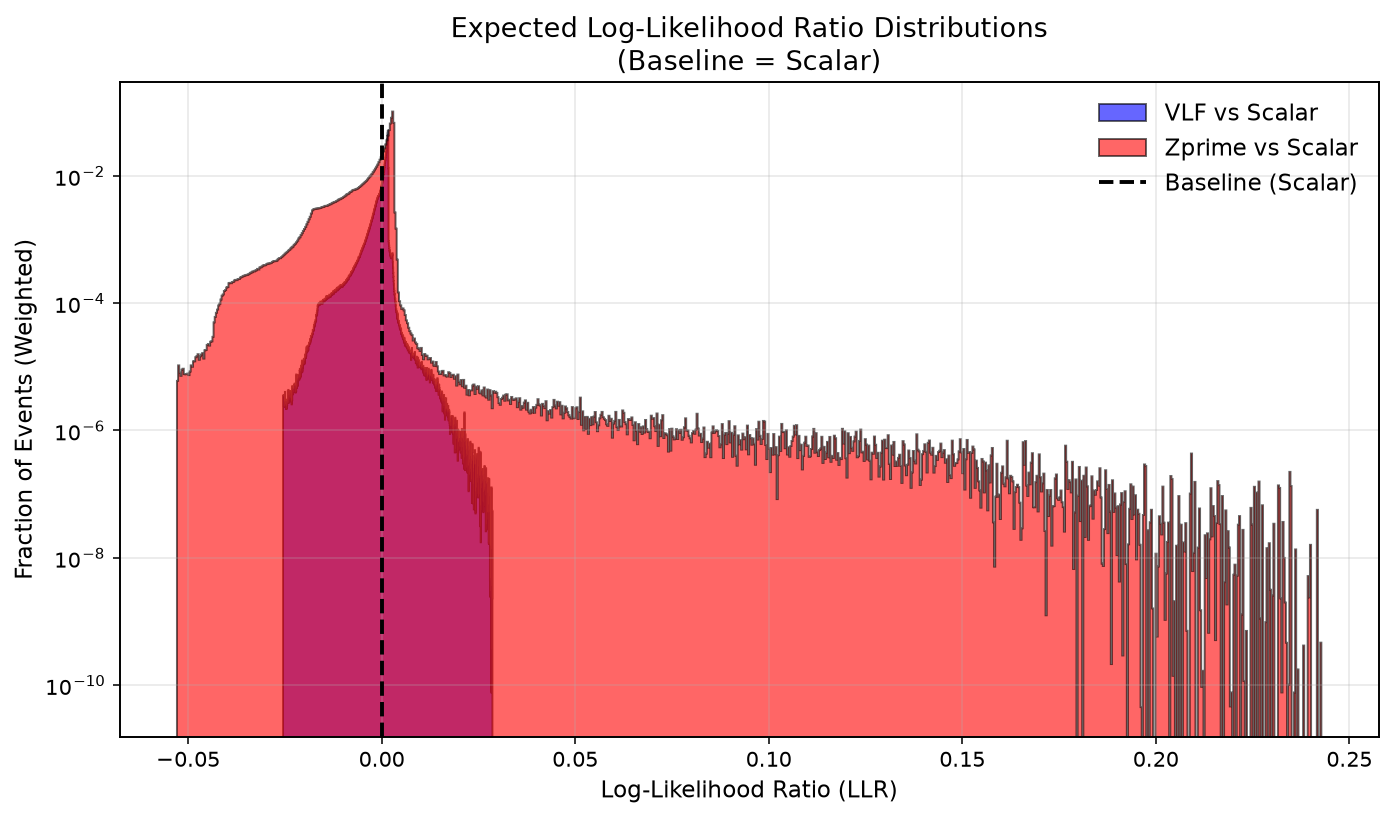

In [35]:
# ==========================================
# 7. PLOT LLR HISTOGRAMS
# ==========================================
print("\n" + "="*60)
print("GENERATING LLR HISTOGRAMS")
print("="*60)

# Create a figure
plt.figure(figsize=(10, 6))

# Define the bins. Using a fixed number of bins, but you can adjust this.
# We filter out NaNs or infinite values just to be safe before plotting.
for model, color in zip(["VLF", "Zprime"], ["blue", "red"]):
    
    # Isolate valid LLR values and their corresponding weights
    valid_mask = np.isfinite(df[f"LLR_Norm_{model}"])
    llr_data = df.loc[valid_mask, f"LLR_Norm_{model}"]
    weights_data = df.loc[valid_mask, "w_i"]
    
    # Plot the weighted histogram
    plt.hist(
        llr_data, 
        bins=1000, 
        weights=weights_data, 
        alpha=0.6, 
        label=f"{model} vs {BASELINE_MODEL}", 
        color=color, 
        histtype='stepfilled', 
        edgecolor='black'
    )

# Formatting the plot
plt.title(f"Expected Log-Likelihood Ratio Distributions\n(Baseline = {BASELINE_MODEL})", fontsize=14)
plt.xlabel("Log-Likelihood Ratio (LLR)", fontsize=12)
plt.ylabel("Fraction of Events (Weighted)", fontsize=12)

# Add a vertical line at 0 for reference (where the Baseline model sits)
plt.axvline(0, color='black', linestyle='--', linewidth=2, label=f'Baseline ({BASELINE_MODEL})')

plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.yscale('log')
#plt.xlim(-1,1)

# Save the plot
plot_output = "/home/vinicius/UnfoldingBSMttbar/LLR_Histograms.png"
plt.savefig(plot_output, dpi=300)
print(f"Success! Histogram saved to: {plot_output}")

# If you are running this in an interactive environment (like Jupyter), uncomment below:
# plt.show()

In [36]:
import scipy.optimize as opt
import numpy as np

# ==========================================
# 6. COMPUTE JOINT LOG-LIKELIHOOD RATIOS & SIGNIFICANCE
# ==========================================
print("\n" + "="*60)
print("COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)")
print("="*60)

# --- 1. Define Luminosity and Expected Events ---
LUMI_FB = 500.0  # integrated luminosity in fb^-1
LUMI_PB = LUMI_FB * 1000.0  # converted to pb^-1 to match cross-sections

# Compute total expected events based on the baseline (data) cross-section
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]
N_events = sigma_baseline * LUMI_PB

print(f"Luminosity      : {LUMI_FB} fb^-1")
print(f"Expected Events : {N_events:.1f}")
print("-" * 60)

# --- 2. Compute the joint log-likelihood ratio for each model ---
joint_llrs = {}

for model in MODELS.keys():

    # Filter out any lingering NaNs to be safe
    valid_mask = ~np.isnan(df[f"Weighted_LLR_{model}"])
    
    # The sum of Weighted_LLR is the expected LLR for a single event.
    # Multiply by N_events to get the Joint LLR for the entire luminosity!
    llr_1event = df.loc[valid_mask, f"Weighted_LLR_{model}"].sum()
    total_llr = llr_1event * N_events
    
    joint_llrs[model] = total_llr
    
    # Calculate Asimov Significance (Z-score)
    # The LLR is expected to be negative because the baseline is the "true" dataset
    if total_llr < 0:
        significance = np.sqrt(-2 * total_llr)
    else:
        # If LLR >= 0, the target is preferred over the baseline 
        # (or it is exactly 0.0 because the target IS the baseline)
        significance = 0.0
    
    y_dm_target = Y_DM_CONFIG[model]["y_dm"]
    
    print(f"Model: {model} [y_dm={y_dm_target}]")
    print(f"  -> Expected LLR (1 event)  : {llr_1event:.6e}")
    print(f"  -> Total Log-Likelihood    : {total_llr:.2f}")
    print(f"  -> Asimov Significance     : {significance:.2f} sigma")
    print("-" * 60)


COMPUTING JOINT LOG-LIKELIHOOD RATIOS (LUMINOSITY SCALED)
Luminosity      : 500.0 fb^-1
Expected Events : 630629.5
------------------------------------------------------------
Model: VLF [y_dm=2.715766]
  -> Expected LLR (1 event)  : -1.344235e-05
  -> Total Log-Likelihood    : -8.48
  -> Asimov Significance     : 4.12 sigma
------------------------------------------------------------
Model: Scalar [y_dm=4.430268]
  -> Expected LLR (1 event)  : 0.000000e+00
  -> Total Log-Likelihood    : 0.00
  -> Asimov Significance     : 0.00 sigma
------------------------------------------------------------
Model: Zprime [y_dm=1.0]
  -> Expected LLR (1 event)  : -2.415231e-03
  -> Total Log-Likelihood    : -1523.12
  -> Asimov Significance     : 55.19 sigma
------------------------------------------------------------


Loading database from /home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_mtt_cut_1000_900.csv.gz...
Loaded 3155536 events.
Computing kinematics, fluxes, and probabilities...
Generating plots...


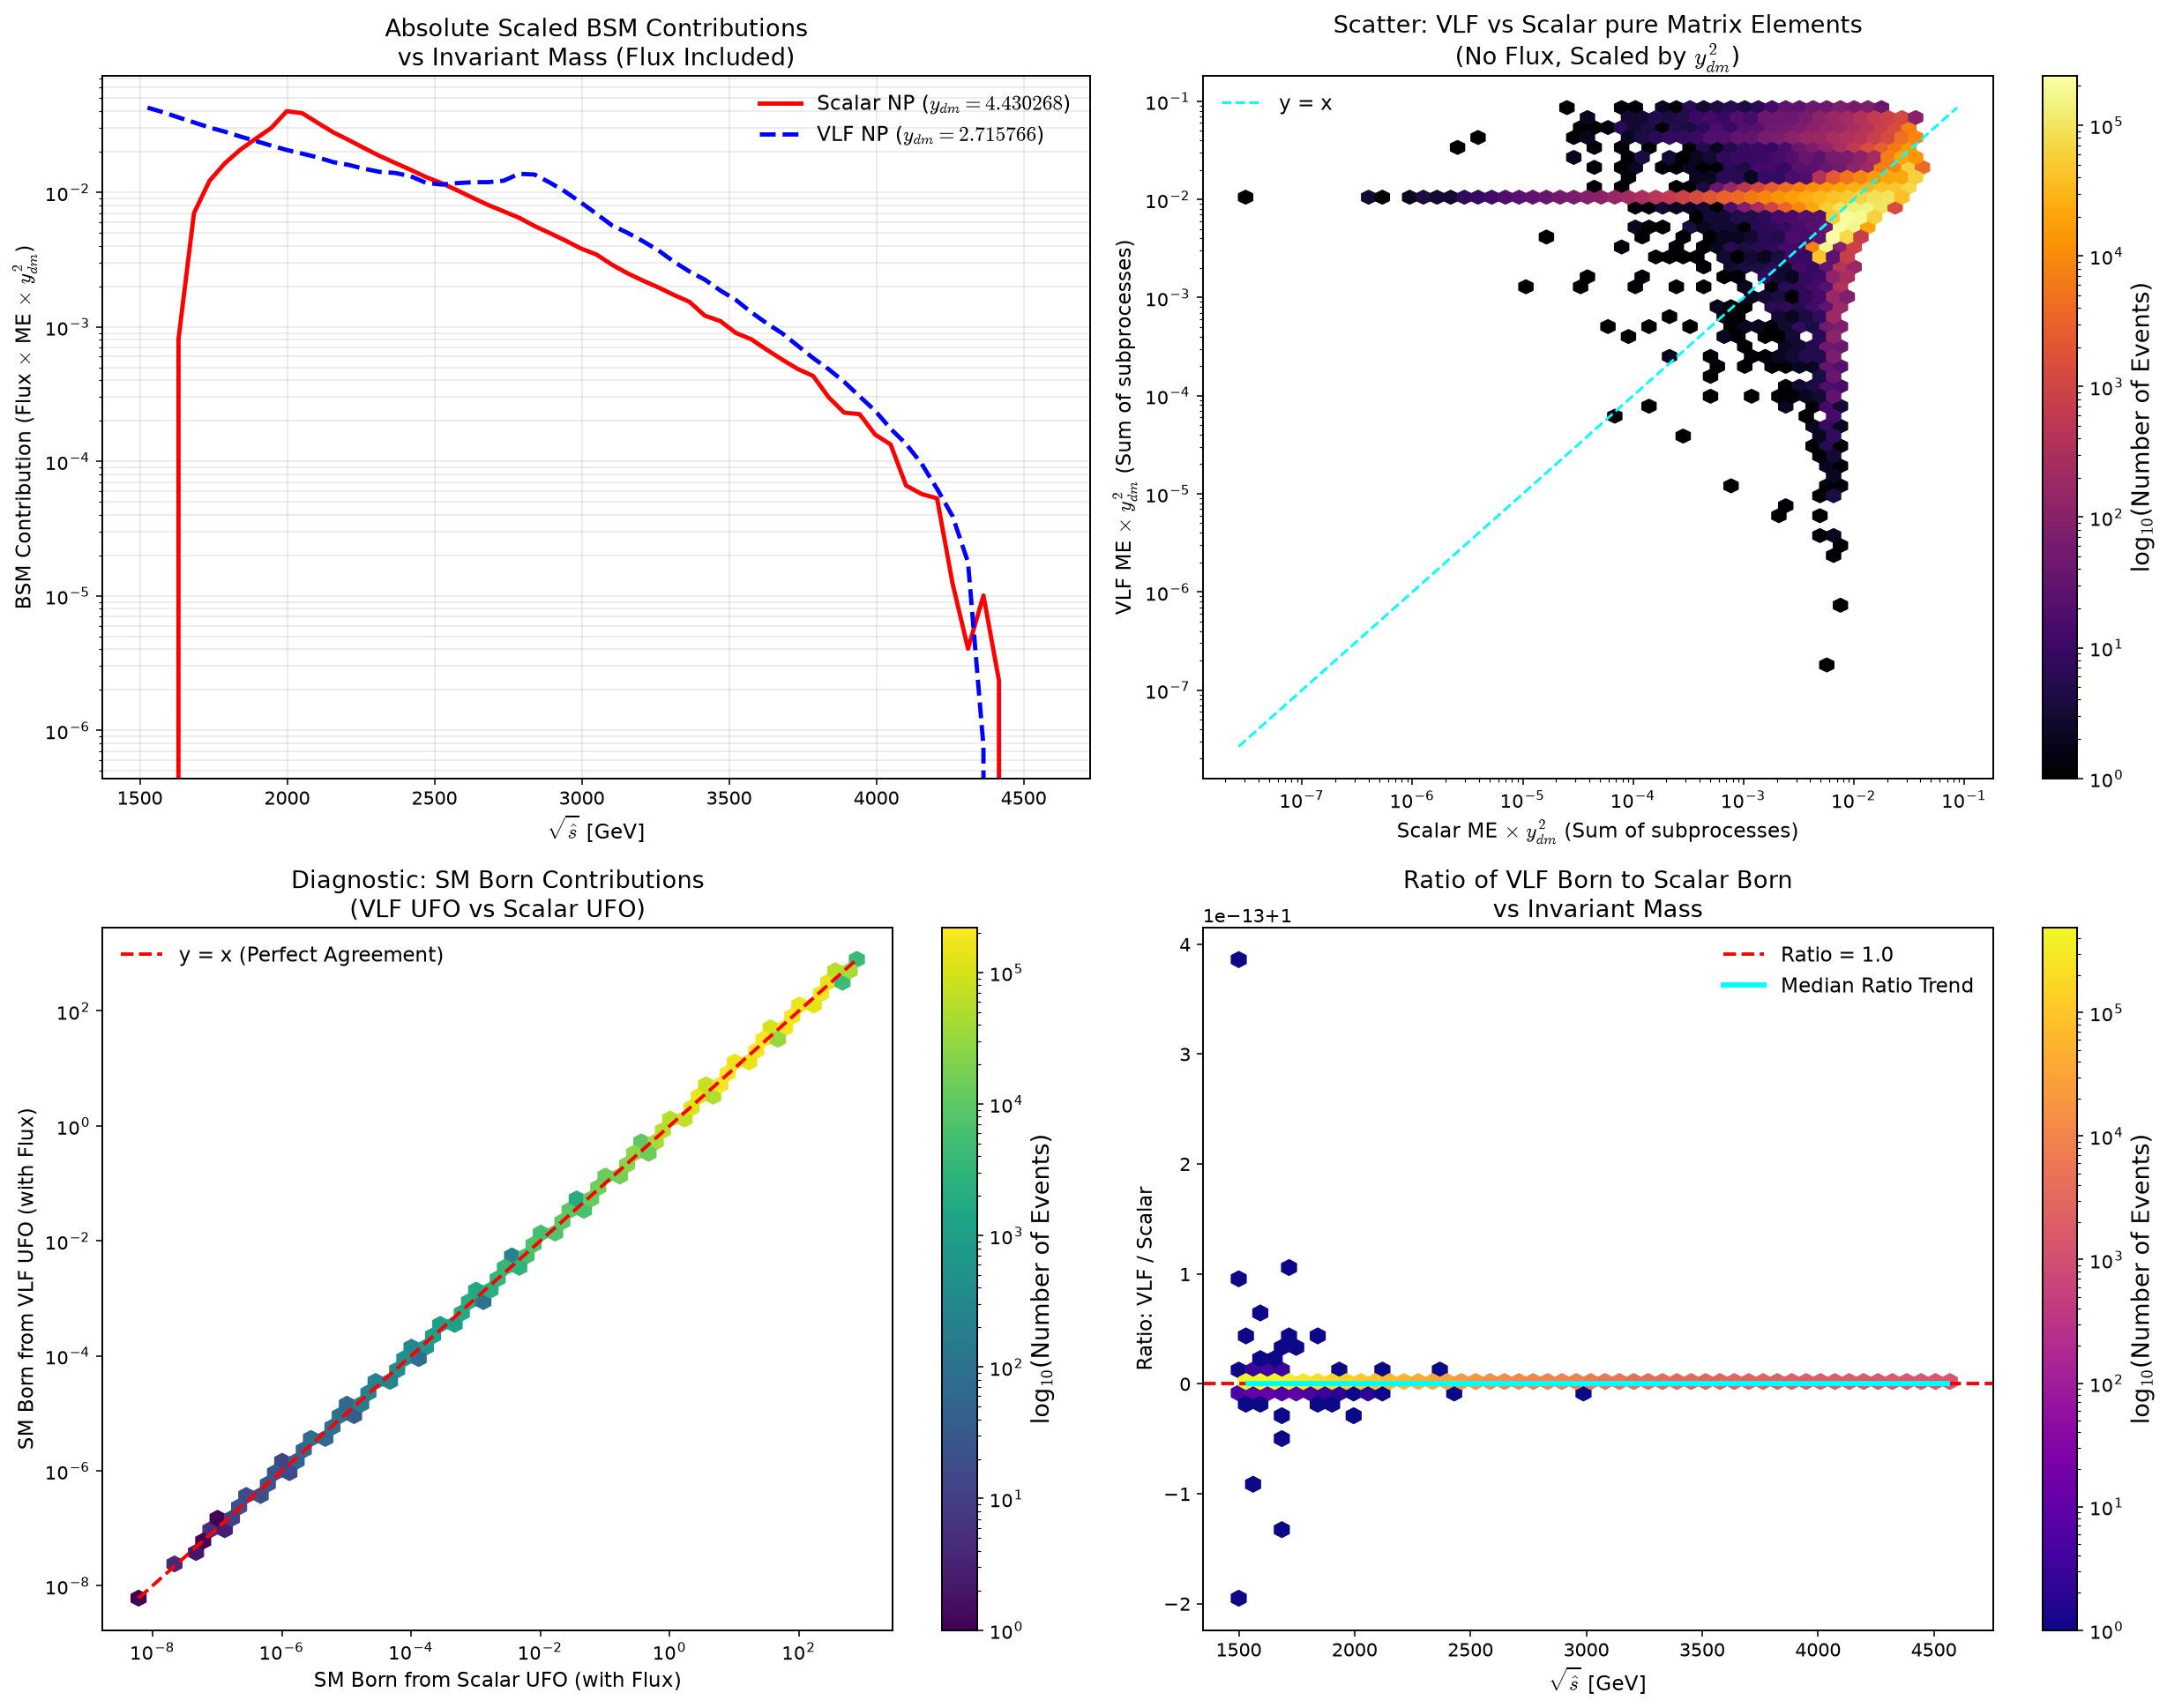

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_mtt_cut_1000_900.csv.gz"


Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} events.")
print("Computing kinematics, fluxes, and probabilities...")

# ==========================================
# 3. COMPUTE CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_vlf = Y_DM_CONFIG["VLF"]["y_dm"] ** Y_DM_CONFIG["VLF"]["power"]

# Define Fluxes for Quarks and Gluons
flux_q = df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"]
flux_g = df["w_gg"]

# --- A. BSM Contributions ---
# With Flux
df["BSM_Scalar_Scaled"] = scale_scalar * (
    (df["w_uux"] * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_Scalar_P2_gg_ttx"])
)
df["BSM_VLF_Scaled"] = scale_vlf * (
    (df["w_uux"] * df["ME_Finite_VLF_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_VLF_P2_gg_ttx"]) 
)

# Without Flux (Pure ME)
df["ME_Scalar_NoFlux"] = scale_scalar * (
    df["ME_Finite_Scalar_P0_uux_ttx"] + df["ME_Finite_Scalar_P2_gg_ttx"]
)
df["ME_VLF_NoFlux"] = scale_vlf * (
    df["ME_Finite_VLF_P0_uux_ttx"] + df["ME_Finite_VLF_P2_gg_ttx"]
)

# --- B. SM Born Contributions (With Flux) ---
df["SM_Born_Scalar_Flux"] = (flux_q * df["ME_Born_Scalar_P0_uux_ttx"]) + (flux_g * df["ME_Born_Scalar_P2_gg_ttx"])
df["SM_Born_VLF_Flux"] = (flux_q * df["ME_Born_VLF_P0_uux_ttx"]) + (flux_g * df["ME_Born_VLF_P2_gg_ttx"])

# Filter safely for plotting log scales on the Born calculations
mask_born = (df["SM_Born_Scalar_Flux"] > 0) & (df["SM_Born_VLF_Flux"] > 0)
df_diag_born = df[mask_born].copy()
df_diag_born["Born_Ratio"] = df_diag_born["SM_Born_VLF_Flux"] / df_diag_born["SM_Born_Scalar_Flux"]

# ==========================================
# 4. PLOTTING (2x2 Grid)
# ==========================================
print("Generating plots...")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
ax1, ax2 = axes[0][0], axes[0][1]
ax3, ax4 = axes[1][0], axes[1][1]

# ---------------------------------------------------------
# Plot 1 (Top-Left): Profile BSM Contributions vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

profile_scalar = df.groupby('s_hat_bin', observed=False)['BSM_Scalar_Scaled'].mean().values
profile_vlf = df.groupby('s_hat_bin', observed=False)['BSM_VLF_Scaled'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_vlf, label=f"VLF NP ($y_{{dm}}={Y_DM_CONFIG['VLF']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Absolute Scaled BSM Contributions\nvs Invariant Mass (Flux Included)", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("BSM Contribution (Flux $\\times$ ME $\\times$ $y_{dm}^2$)", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2 (Top-Right): Scatter of Pure BSM Matrix Elements (No Flux)
# ---------------------------------------------------------
mask_me = (df["ME_Scalar_NoFlux"] > 0) & (df["ME_VLF_NoFlux"] > 0)
df_scatter = df[mask_me]

hb2 = ax2.hexbin(df_scatter["ME_Scalar_NoFlux"], df_scatter["ME_VLF_NoFlux"], 
                 xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

min_val2 = min(df_scatter["ME_Scalar_NoFlux"].min(), df_scatter["ME_VLF_NoFlux"].min())
max_val2 = max(df_scatter["ME_Scalar_NoFlux"].max(), df_scatter["ME_VLF_NoFlux"].max())
ax2.plot([min_val2, max_val2], [min_val2, max_val2], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: VLF vs Scalar pure Matrix Elements\n(No Flux, Scaled by $y_{dm}^2$)", fontsize=14)
ax2.set_xlabel("Scalar ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.set_ylabel("VLF ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.legend(fontsize=12)
cb2 = fig.colorbar(hb2, ax=ax2)
cb2.set_label('log$_{10}$(Number of Events)')

# ---------------------------------------------------------
# Plot 3 (Bottom-Left): Scatter of SM Born VLF vs SM Born Scalar
# ---------------------------------------------------------
hb3 = ax3.hexbin(df_diag_born["SM_Born_Scalar_Flux"], df_diag_born["SM_Born_VLF_Flux"], 
                 xscale='log', yscale='log', gridsize=50, cmap='viridis', bins='log')

min_val3 = min(df_diag_born["SM_Born_Scalar_Flux"].min(), df_diag_born["SM_Born_VLF_Flux"].min())
max_val3 = max(df_diag_born["SM_Born_Scalar_Flux"].max(), df_diag_born["SM_Born_VLF_Flux"].max())
ax3.plot([min_val3, max_val3], [min_val3, max_val3], color='red', linestyle='--', linewidth=2, label='y = x (Perfect Agreement)')

ax3.set_title("Diagnostic: SM Born Contributions\n(VLF UFO vs Scalar UFO)", fontsize=14)
ax3.set_xlabel("SM Born from Scalar UFO (with Flux)", fontsize=12)
ax3.set_ylabel("SM Born from VLF UFO (with Flux)", fontsize=12)
ax3.legend(fontsize=12)
cb3 = fig.colorbar(hb3, ax=ax3)
cb3.set_label('log$_{10}$(Number of Events)')

# ---------------------------------------------------------
# Plot 4 (Bottom-Right): Ratio of Borns vs Invariant Mass
# ---------------------------------------------------------
hb4 = ax4.hexbin(df_diag_born["sqrt_s_hat"], df_diag_born["Born_Ratio"], 
                 gridsize=50, cmap='plasma', bins='log')

ax4.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Ratio = 1.0')

bins_diag = np.linspace(df_diag_born["sqrt_s_hat"].min(), df_diag_born["sqrt_s_hat"].max(), 40)
bin_centers_diag = 0.5 * (bins_diag[:-1] + bins_diag[1:])
df_diag_born['s_hat_bin_diag'] = pd.cut(df_diag_born['sqrt_s_hat'], bins=bins_diag)
profile_ratio = df_diag_born.groupby('s_hat_bin_diag', observed=False)['Born_Ratio'].median().values

ax4.plot(bin_centers_diag, profile_ratio, color='cyan', linewidth=3, label='Median Ratio Trend')

ax4.set_title("Ratio of VLF Born to Scalar Born\nvs Invariant Mass", fontsize=14)
ax4.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax4.set_ylabel("Ratio: VLF / Scalar", fontsize=12)
ax4.legend(fontsize=12)
cb4 = fig.colorbar(hb4, ax=ax4)
cb4.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

Looking for files matching: /home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_*.csv.gz
Found 3 files. Loading and concatenating...
Loaded a total of 11911179 events.
Clipping unphysical PDF fluxes, computing kinematics and probabilities...
Generating plots...


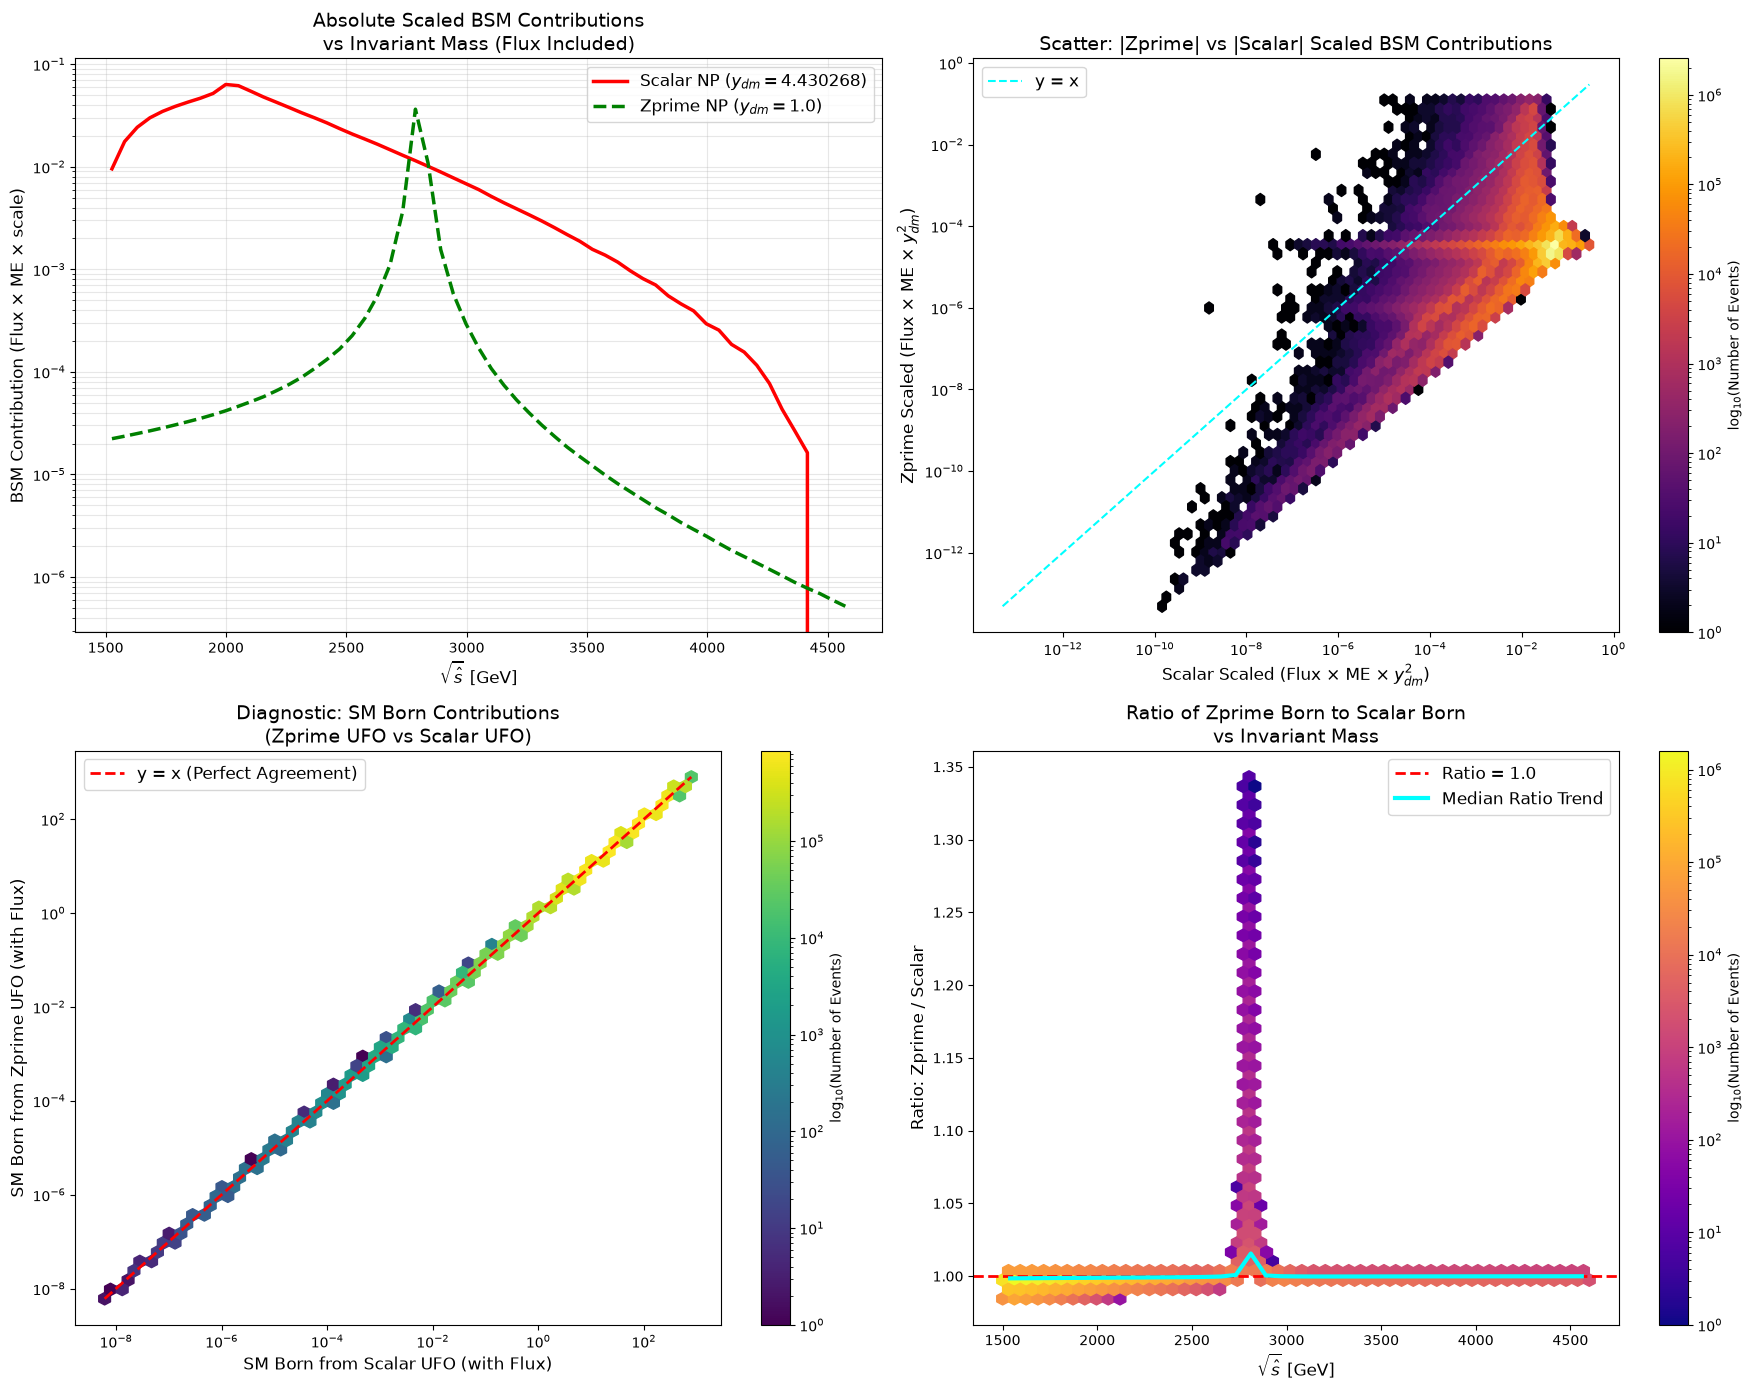

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import gc

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV_PATTERN = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_*.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

# ==========================================
# 2. LOAD DATA (USING GLOB)
# ==========================================
print(f"Looking for files matching: {INPUT_CSV_PATTERN}")
csv_files = sorted(list(glob.glob(INPUT_CSV_PATTERN)))

if not csv_files:
    raise FileNotFoundError(f"No files found matching the pattern.")

print(f"Found {len(csv_files)} files. Loading and concatenating...")

dataframes = []
for file_path in csv_files:
    df_temp = pd.read_csv(file_path)
    dataframes.append(df_temp)

df = pd.concat(dataframes, ignore_index=True)
del dataframes
gc.collect()

print(f"Loaded a total of {len(df)} events.")
print("Clipping unphysical PDF fluxes, computing kinematics and probabilities...")

# ==========================================
# 3. COMPUTE CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_zprime = Y_DM_CONFIG["Zprime"]["y_dm"] ** Y_DM_CONFIG["Zprime"]["power"]

# ---------------------------------------------------------
# THE FIX: Component-by-Component Flux Clipping
# ---------------------------------------------------------
# We clip the native columns to exactly zero to ensure no negative 
# PDF artifacts propagate into any downstream sum or product.
for flavor in ["w_uux", "w_ddx", "w_ccx", "w_ssx", "w_bbx", "w_gg"]:
    if flavor in df.columns:
        df[flavor] = np.clip(df[flavor], a_min=0.0, a_max=None)

# Define Fluxes safely using the clipped columns
flux_q_sym = df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"]
flux_g = df["w_gg"]

# --- A. BSM Contributions ---
# With Flux
df["BSM_Scalar_Scaled"] = scale_scalar * (
    (flux_q_sym * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    (flux_g     * df["ME_Finite_Scalar_P2_gg_ttx"])
)

df["BSM_Zprime_Scaled"] = scale_zprime * (
    (df["w_uux"] * df["ME_Born_NP_Zprime_P2_uux_ttx"]) + 
    (df["w_ddx"] * df["ME_Born_NP_Zprime_P3_ddx_ttx"]) + 
    (flux_g      * df["ME_Born_NP_Zprime_P0_gg_ttx"]) 
)

# Without Flux (Pure ME)
df["ME_Scalar_NoFlux"] = scale_scalar * (
    df["ME_Finite_Scalar_P0_uux_ttx"] + df["ME_Finite_Scalar_P2_gg_ttx"]
)

df["ME_Zprime_NoFlux"] = scale_zprime * (
    df["ME_Born_NP_Zprime_P2_uux_ttx"] + 
    df["ME_Born_NP_Zprime_P3_ddx_ttx"] + 
    df["ME_Born_NP_Zprime_P0_gg_ttx"]
)

# --- B. SM Born Contributions (With Flux) ---
df["SM_Born_Scalar_Flux"] = (flux_q_sym * df["ME_Born_Scalar_P0_uux_ttx"]) + (flux_g * df["ME_Born_Scalar_P2_gg_ttx"])

df["SM_Born_Zprime_Flux"] = (
    (df["w_uux"] * df["ME_Born_SM_Zprime_P2_uux_ttx"]) + 
    (df["w_ddx"] * df["ME_Born_SM_Zprime_P3_ddx_ttx"]) + 
    (flux_g      * df["ME_Born_SM_Zprime_P0_gg_ttx"])
)

# Filter safely for plotting log scales on the Born calculations
mask_born = (df["SM_Born_Scalar_Flux"] > 0) & (df["SM_Born_Zprime_Flux"] > 0)
df_diag_born = df[mask_born].copy()
df_diag_born["Born_Ratio"] = df_diag_born["SM_Born_Zprime_Flux"] / df_diag_born["SM_Born_Scalar_Flux"]

# ==========================================
# 4. PLOTTING (2x2 Grid)
# ==========================================
print("Generating plots...")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
ax1, ax2 = axes[0][0], axes[0][1]
ax3, ax4 = axes[1][0], axes[1][1]

# ---------------------------------------------------------
# Plot 1 (Top-Left): Profile BSM Contributions vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

profile_scalar = df.groupby('s_hat_bin', observed=False)['BSM_Scalar_Scaled'].mean().values
profile_zprime = df.groupby('s_hat_bin', observed=False)['BSM_Zprime_Scaled'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_zprime, label=f"Zprime NP ($y_{{dm}}={Y_DM_CONFIG['Zprime']['y_dm']}$)", color='green', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Absolute Scaled BSM Contributions\nvs Invariant Mass (Flux Included)", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("BSM Contribution (Flux $\\times$ ME $\\times$ scale)", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2 (Top-Right): Scatter of Pure BSM Matrix Elements
# ---------------------------------------------------------
# Taking absolute values to prevent log-scale warnings from interference terms
mask_me = (df["BSM_Scalar_Scaled"].abs() > 0) & (df["BSM_Zprime_Scaled"].abs() > 0)
df_scatter = df[mask_me]

hb2 = ax2.hexbin(df_scatter["BSM_Scalar_Scaled"].abs(), df_scatter["BSM_Zprime_Scaled"].abs(), 
                 xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

min_val2 = min(df_scatter["BSM_Scalar_Scaled"].abs().min(), df_scatter["BSM_Zprime_Scaled"].abs().min())
max_val2 = max(df_scatter["BSM_Scalar_Scaled"].abs().max(), df_scatter["BSM_Zprime_Scaled"].abs().max())
ax2.plot([min_val2, max_val2], [min_val2, max_val2], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: |Zprime| vs |Scalar| Scaled BSM Contributions", fontsize=14)
ax2.set_xlabel("Scalar Scaled (Flux $\\times$ ME $\\times \\; y_{dm}^2$)", fontsize=12)
ax2.set_ylabel("Zprime Scaled (Flux $\\times$ ME $\\times \\; y_{dm}^2$)", fontsize=12)
ax2.legend(fontsize=12)
cb2 = fig.colorbar(hb2, ax=ax2)
cb2.set_label('log$_{10}$(Number of Events)')

# ---------------------------------------------------------
# Plot 3 (Bottom-Left): Scatter of SM Born Zprime vs SM Born Scalar
# ---------------------------------------------------------
hb3 = ax3.hexbin(df_diag_born["SM_Born_Scalar_Flux"], df_diag_born["SM_Born_Zprime_Flux"], 
                 xscale='log', yscale='log', gridsize=50, cmap='viridis', bins='log')

min_val3 = min(df_diag_born["SM_Born_Scalar_Flux"].min(), df_diag_born["SM_Born_Zprime_Flux"].min())
max_val3 = max(df_diag_born["SM_Born_Scalar_Flux"].max(), df_diag_born["SM_Born_Zprime_Flux"].max())
ax3.plot([min_val3, max_val3], [min_val3, max_val3], color='red', linestyle='--', linewidth=2, label='y = x (Perfect Agreement)')

ax3.set_title("Diagnostic: SM Born Contributions\n(Zprime UFO vs Scalar UFO)", fontsize=14)
ax3.set_xlabel("SM Born from Scalar UFO (with Flux)", fontsize=12)
ax3.set_ylabel("SM Born from Zprime UFO (with Flux)", fontsize=12)
ax3.legend(fontsize=12)
cb3 = fig.colorbar(hb3, ax=ax3)
cb3.set_label('log$_{10}$(Number of Events)')

# ---------------------------------------------------------
# Plot 4 (Bottom-Right): Ratio of Borns vs Invariant Mass
# ---------------------------------------------------------
hb4 = ax4.hexbin(df_diag_born["sqrt_s_hat"], df_diag_born["Born_Ratio"], 
                 gridsize=50, cmap='plasma', bins='log')

ax4.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Ratio = 1.0')

bins_diag = np.linspace(df_diag_born["sqrt_s_hat"].min(), df_diag_born["sqrt_s_hat"].max(), 40)
bin_centers_diag = 0.5 * (bins_diag[:-1] + bins_diag[1:])
df_diag_born['s_hat_bin_diag'] = pd.cut(df_diag_born['sqrt_s_hat'], bins=bins_diag)
profile_ratio = df_diag_born.groupby('s_hat_bin_diag', observed=False)['Born_Ratio'].median().values

ax4.plot(bin_centers_diag, profile_ratio, color='cyan', linewidth=3, label='Median Ratio Trend')

ax4.set_title("Ratio of Zprime Born to Scalar Born\nvs Invariant Mass", fontsize=14)
ax4.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax4.set_ylabel("Ratio: Zprime / Scalar", fontsize=12)
ax4.legend(fontsize=12)
cb4 = fig.colorbar(hb4, ax=ax4)
cb4.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

# Including Systematics

In [3]:
import pandas as pd
import numpy as np
import glob
import gc
import os

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_PATTERN = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_*.csv.gz"
OUTPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/Likelihoods_Profiled_Scan.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

MODELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": ["P2_uux_ttx", "P3_ddx_ttx", "P0_gg_ttx"]
}

CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590,  
    "Zprime": 1.2571816  
}

BASELINE_MODEL = "Scalar"
SYS_ERRORS = [0.0, 0.02, 0.05, 0.1, 0.3]  

LUMI_FB = 3000.0 
LUMI_PB = LUMI_FB * 1000.0
sigma_baseline = CROSS_SECTIONS[BASELINE_MODEL]
N_events = sigma_baseline * LUMI_PB

# Remove previous output file to prevent infinite appending if rerun
if os.path.exists(OUTPUT_CSV):
    os.remove(OUTPUT_CSV)

# ==========================================
# 2. PASS 1: COMPUTE GLOBAL NORMALIZATION 
# ==========================================
print(f"Looking for files matching: {INPUT_PATTERN}")
csv_files = sorted(list(glob.glob(INPUT_PATTERN)))

if not csv_files:
    raise FileNotFoundError(f"No files found matching the pattern: {INPUT_PATTERN}")

print("\n" + "="*60)
print("PASS 1: Computing Global Event Weights (Low RAM Mode)")
print("="*60)

global_mg_weight_sum = 0.0
total_valid_events = 0

for file_path in csv_files:
    # Only load the weight column to save maximum memory
    df_temp = pd.read_csv(file_path, usecols=["mg_weight"])
    df_temp = df_temp[df_temp["mg_weight"] >= 0]
    
    global_mg_weight_sum += df_temp["mg_weight"].sum()
    total_valid_events += len(df_temp)
    
    del df_temp
    gc.collect()

print(f"Total Physical Events Kept: {total_valid_events:,}")
print(f"Global Weight Sum: {global_mg_weight_sum:.6e}")
print(f"Expected Total Events (N_events): {N_events:.1f} (Lumi = {LUMI_FB} fb^-1)")

# ==========================================
# 3. PASS 2: COMPUTE, PROFILE, & STREAM TO DISK
# ==========================================
print("\n" + "="*60)
print("PASS 2: Processing Matrix Elements & Profiling Systematics")
print("="*60)

# Accumulators for the final significance calculation
sum_weighted_llr = {eps: {m: 0.0 for m in MODELS} for eps in SYS_ERRORS}
sum_theta        = {eps: {m: 0.0 for m in MODELS} for eps in SYS_ERRORS}
eps_safeguard    = 1e-300
first_chunk      = True

for file_idx, file_path in enumerate(csv_files):
    print(f"  -> Processing File {file_idx + 1}/{len(csv_files)}: {os.path.basename(file_path)}")
    
    df = pd.read_csv(file_path)
    df = df[df["mg_weight"] >= 0].reset_index(drop=True)
    
    # Apply global normalization computed in Pass 1
    df["w_i"] = df["mg_weight"] / global_mg_weight_sum
    
    # --- A. Precompute Base Probabilities ---
    for model, channels in MODELS.items():
        y_dm = Y_DM_CONFIG[model]["y_dm"]
        scale_factor = y_dm ** Y_DM_CONFIG[model]["power"]
        
        p_sm_total = np.zeros(len(df))
        p_bsm_leading = np.zeros(len(df))
        
        for ch in channels:
            parton_pair = ch.split('_')[1]
            if model in ["VLF", "Scalar"] and parton_pair == "uux":
                flux = (
                    np.clip(df["w_uux"], a_min=0.0, a_max=None) + 
                    np.clip(df["w_ddx"], a_min=0.0, a_max=None) + 
                    np.clip(df["w_ccx"], a_min=0.0, a_max=None) + 
                    np.clip(df["w_ssx"], a_min=0.0, a_max=None) + 
                    np.clip(df["w_bbx"], a_min=0.0, a_max=None)
                )
            else:
                # Clip the single channel flux
                flux = np.clip(df[f"w_{parton_pair}"], a_min=0.0, a_max=None)
                
            # Select the correct column names
            if model == "Zprime":
                if ch == "P2_uux_ttx" or ch == "P3_ddx_ttx":
                    sm_col  = "ME_Born_Scalar_P0_uux_ttx" 
                else:
                    sm_col  = "ME_Born_Scalar_P2_gg_ttx"
                bsm_col = f"ME_Born_NP_{model}_{ch}"
            else:
                sm_col  = f"ME_Born_{model}_{ch}"
                bsm_col = f"ME_Finite_{model}_{ch}"
                
            p_sm_total += flux * df[sm_col]
            p_bsm_leading += flux * df[bsm_col]
            
        df[f"P_SM_Base_{model}"] = p_sm_total
        df[f"P_BSM_Scaled_{model}"] = p_bsm_leading * scale_factor
    

    # --- B. Loop Over Epsilons ---
    for eps in SYS_ERRORS:
        # Profile Theta for each model
        for model in MODELS.keys():
            A = df[f"P_SM_Base_{model}"] * eps
            B = df[f"P_SM_Base_{model}"] + df[f"P_BSM_Scaled_{model}"]
            
            theta_i = np.where(A > 1e-12, (-B + np.sqrt(B**2 + 4 * A**2)) / (2 * A), 0.0)
            p_prof = B + (A * theta_i)
            penalty_i = 0.5 * (theta_i ** 2)
            
            df[f"Theta_{model}_eps{eps}"] = theta_i
            df[f"P_Prof_{model}_eps{eps}"] = p_prof
            df[f"Penalty_{model}_eps{eps}"] = penalty_i

        # Compute Log-Likelihood Ratios
        p_base_safe = np.clip(df[f"P_Prof_{BASELINE_MODEL}_eps{eps}"], a_min=eps_safeguard, a_max=None)
        log_p_base = np.log(p_base_safe / sigma_baseline) - df[f"Penalty_{BASELINE_MODEL}_eps{eps}"]
        
        for model in MODELS.keys():
            p_targ_safe = np.clip(df[f"P_Prof_{model}_eps{eps}"], a_min=eps_safeguard, a_max=None)
            log_p_targ = np.log(p_targ_safe / CROSS_SECTIONS[model]) - df[f"Penalty_{model}_eps{eps}"]
            
            llr_norm = log_p_targ - log_p_base
            weighted_llr = df["w_i"] * llr_norm
            
            df[f"Weighted_LLR_{model}_eps{eps}"] = weighted_llr
            
            # Accumulate running totals for final significance
            sum_weighted_llr[eps][model] += weighted_llr.sum()
            sum_theta[eps][model] += df[f"Theta_{model}_eps{eps}"].sum()

    # --- C. Stream to Disk and Clear RAM ---
    #if first_chunk:
    #    df.to_csv(OUTPUT_CSV, mode='w', header=True, index=False, compression='gzip')
    #    first_chunk = False
    #else:
    #    df.to_csv(OUTPUT_CSV, mode='a', header=False, index=False, compression='gzip')

    del df
    gc.collect()

print(f"\nAll files processed successfully! Full profiled dataset saved to: {OUTPUT_CSV}")

# ==========================================
# 4. COMPUTE FINAL METRICS & PRINT SUMMARY
# ==========================================
summary_results = []

for eps in SYS_ERRORS:
    for model in MODELS.keys():
        llr_1event = sum_weighted_llr[eps][model]
        total_llr = llr_1event * N_events
        sig = np.sqrt(-2 * total_llr) if total_llr < 0 else 0.0
        
        mean_theta = sum_theta[eps][model] / total_valid_events
        
        summary_results.append({
            "Model": model,
            "Epsilon": eps,
            "Mean_Theta": mean_theta,
            "Significance": sig
        })

df_summary = pd.DataFrame(summary_results)

print("\n" + "="*50)
print("ASIMOV SIGNIFICANCE (Z-SCORE) VS. SYSTEMATIC ERROR")
print("="*50)
pivot_sig = df_summary.pivot(index="Model", columns="Epsilon", values="Significance")
print(pivot_sig.to_string(float_format="%.2f"))

print("\n" + "="*50)
print("MEAN THETA VS. SYSTEMATIC ERROR (BIAS CHECK)")
print("="*50)
pivot_theta = df_summary.pivot(index="Model", columns="Epsilon", values="Mean_Theta")
print(pivot_theta.to_string(float_format="%+.4f"))
print("="*50)

Looking for files matching: /home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_*.csv.gz

PASS 1: Computing Global Event Weights (Low RAM Mode)
Total Physical Events Kept: 11,910,996
Global Weight Sum: 3.800407e+00
Expected Total Events (N_events): 3783777.0 (Lumi = 3000.0 fb^-1)

PASS 2: Processing Matrix Elements & Profiling Systematics
  -> Processing File 1/3: Matrix_AllModels_mtt_cut3_1000_900.csv.gz
  -> Processing File 2/3: Matrix_AllModels_mtt_cut4_1000_900.csv.gz
  -> Processing File 3/3: Matrix_AllModels_mtt_cut_1000_900.csv.gz

All files processed successfully! Full profiled dataset saved to: /home/vinicius/UnfoldingBSMttbar/Likelihoods_Profiled_Scan.csv.gz

ASIMOV SIGNIFICANCE (Z-SCORE) VS. SYSTEMATIC ERROR
Epsilon   0.00   0.02   0.05   0.10   0.30
Model                                     
Scalar    0.00   0.00   0.00   0.00   0.00
VLF      10.09   9.91   8.96   4.12   0.00
Zprime  135.19 135.16 134.97 134.31 128.06

MEAN THETA VS. SYSTEMATIC ERROR (

# Debug plots and codes

Loading database from /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_newZ.csv.gz...
Loaded 3155536 events.
Computing and plotting...


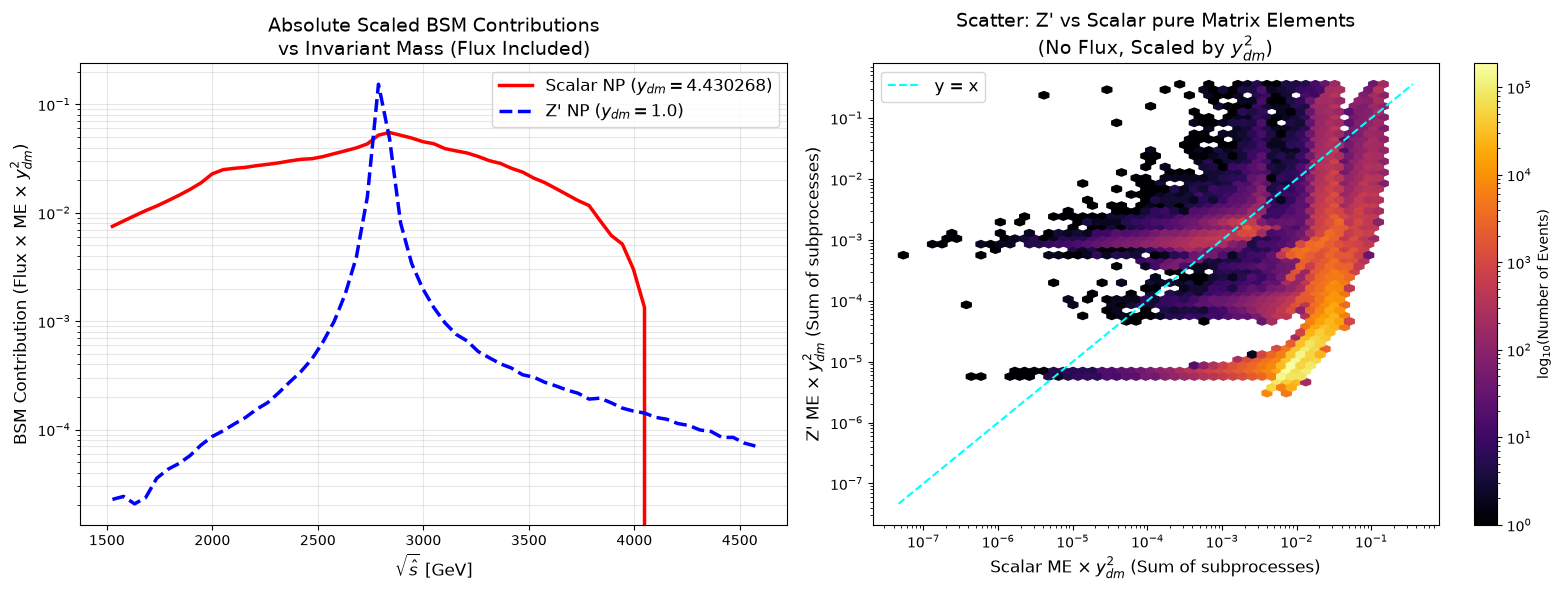

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_newZ.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} events.")
print("Computing and plotting...")

# ==========================================
# 3. COMPUTE CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_zprime = Y_DM_CONFIG["Zprime"]["y_dm"] ** Y_DM_CONFIG["Zprime"]["power"]

# --- For Plot 1: With Flux ---
df["BSM_Scalar_Scaled"] = scale_scalar * (
    (df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    ( df["ME_Finite_Scalar_P2_gg_ttx"])
)
df["BSM_Zprime_Scaled"] = scale_zprime * (
    (df["ME_Born_NP_Zprime_P2_uux_ttx"]) + 
    ( df["ME_Born_NP_Zprime_P3_ddx_ttx"]) +
    (df["ME_Born_NP_Zprime_P0_gg_ttx"]) 
)

# --- For Plot 2: Without Flux (Just pure ME * y_dm^2) ---
df["ME_Scalar_NoFlux"] = scale_scalar * (
    df["ME_Finite_Scalar_P0_uux_ttx"] + 
    df["ME_Finite_Scalar_P2_gg_ttx"]
)
df["ME_Zprime_NoFlux"] = scale_zprime * (
    df["ME_Born_NP_Zprime_P2_uux_ttx"] + 
    df["ME_Born_NP_Zprime_P3_ddx_ttx"] + 
    df["ME_Born_NP_Zprime_P0_gg_ttx"]
)

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Profile Plot vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

profile_scalar = df.groupby('s_hat_bin', observed=False)['BSM_Scalar_Scaled'].mean().values
profile_zprime = df.groupby('s_hat_bin', observed=False)['BSM_Zprime_Scaled'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_zprime, label=f"Z' NP ($y_{{dm}}={Y_DM_CONFIG['Zprime']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Absolute Scaled BSM Contributions\nvs Invariant Mass (Flux Included)", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("BSM Contribution (Flux $\\times$ ME $\\times$ $y_{dm}^2$)", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2: Scatter Plot of Pure Matrix Elements (No Flux)
# ---------------------------------------------------------
# Filter out exact zeros to safely use a log-log scale
mask = (df["ME_Scalar_NoFlux"] > 0) & (df["ME_Zprime_NoFlux"] > 0)
df_scatter = df[mask]

# Density scatter plot (hexbin) for safe rendering of millions of points
hb = ax2.hexbin(df_scatter["ME_Scalar_NoFlux"], df_scatter["ME_Zprime_NoFlux"], 
                xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

# Add a y = x reference line
min_val = min(df_scatter["ME_Scalar_NoFlux"].min(), df_scatter["ME_Zprime_NoFlux"].min())
max_val = max(df_scatter["ME_Scalar_NoFlux"].max(), df_scatter["ME_Zprime_NoFlux"].max())
ax2.plot([min_val, max_val], [min_val, max_val], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: Z' vs Scalar pure Matrix Elements\n(No Flux, Scaled by $y_{dm}^2$)", fontsize=14)
ax2.set_xlabel("Scalar ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.set_ylabel("Z' ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.legend(fontsize=12)

# Add colorbar for the density
cb = fig.colorbar(hb, ax=ax2)
cb.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

Loading database from /home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_mtt_cut4_1000_900.csv.gz...
Loaded 4985053 events.
Computing and plotting...


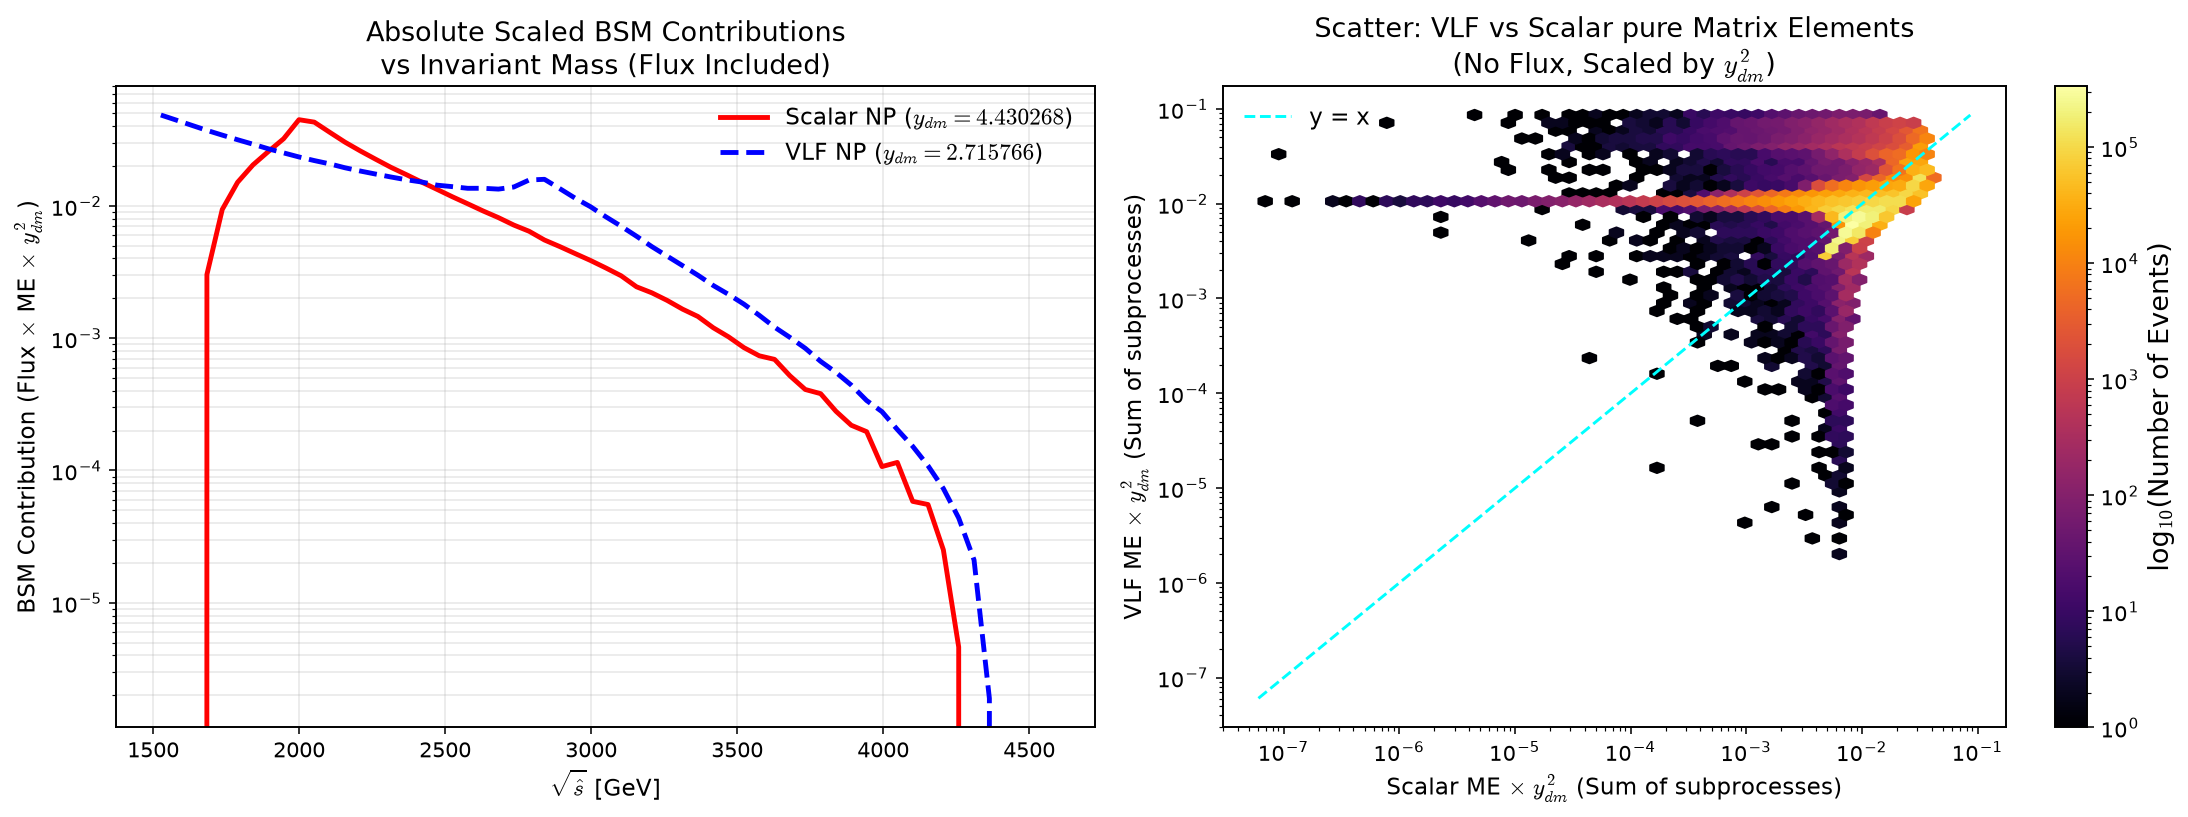

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_mtt_cut4_1000_900.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} events.")
print("Computing and plotting...")

# ==========================================
# 3. COMPUTE CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_vlf = Y_DM_CONFIG["VLF"]["y_dm"] ** Y_DM_CONFIG["VLF"]["power"]

# --- For Plot 1: With Flux ---
df["BSM_Scalar_Scaled"] = scale_scalar * (
    (df["w_uux"] * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_Scalar_P2_gg_ttx"])
)
df["BSM_VLF_Scaled"] = scale_vlf * (
    (df["w_uux"] * df["ME_Finite_VLF_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_VLF_P2_gg_ttx"]) 
)

# --- For Plot 2: Without Flux (Just pure ME * y_dm^2) ---
df["ME_Scalar_NoFlux"] = scale_scalar * (
    df["ME_Finite_Scalar_P0_uux_ttx"] + 
    df["ME_Finite_Scalar_P2_gg_ttx"]
)
df["ME_VLF_NoFlux"] = scale_vlf * (
    df["ME_Finite_VLF_P0_uux_ttx"] + 
    df["ME_Finite_VLF_P2_gg_ttx"]
)

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Profile Plot vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

profile_scalar = df.groupby('s_hat_bin', observed=False)['BSM_Scalar_Scaled'].mean().values
profile_vlf = df.groupby('s_hat_bin', observed=False)['BSM_VLF_Scaled'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_vlf, label=f"VLF NP ($y_{{dm}}={Y_DM_CONFIG['VLF']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Absolute Scaled BSM Contributions\nvs Invariant Mass (Flux Included)", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("BSM Contribution (Flux $\\times$ ME $\\times$ $y_{dm}^2$)", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2: Scatter Plot of Pure Matrix Elements (No Flux)
# ---------------------------------------------------------
# Filter out exact zeros to safely use a log-log scale
mask = (df["ME_Scalar_NoFlux"] > 0) & (df["ME_VLF_NoFlux"] > 0)
df_scatter = df[mask]

# Density scatter plot (hexbin) for safe rendering of millions of points
hb = ax2.hexbin(df_scatter["ME_Scalar_NoFlux"], df_scatter["ME_VLF_NoFlux"], 
                xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

# Add a y = x reference line
min_val = min(df_scatter["ME_Scalar_NoFlux"].min(), df_scatter["ME_VLF_NoFlux"].min())
max_val = max(df_scatter["ME_Scalar_NoFlux"].max(), df_scatter["ME_VLF_NoFlux"].max())
ax2.plot([min_val, max_val], [min_val, max_val], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: VLF vs Scalar pure Matrix Elements\n(No Flux, Scaled by $y_{dm}^2$)", fontsize=14)
ax2.set_xlabel("Scalar ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.set_ylabel("VLF ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.legend(fontsize=12)

# Add colorbar for the density
cb = fig.colorbar(hb, ax=ax2)
cb.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

Loading database from /home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_newPDF.csv.gz...
Loaded 3155536 events.
Computing and plotting...


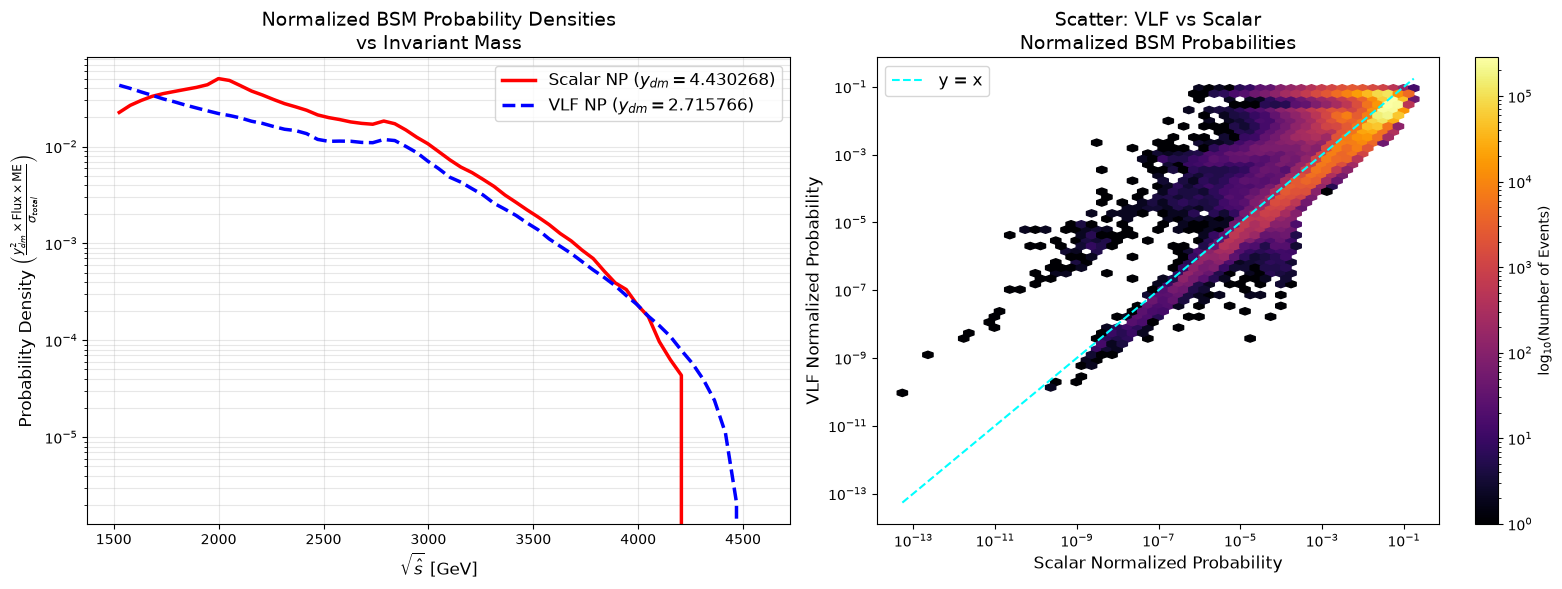

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/Matrix_AllModels_newPDF.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590,  
    "Zprime": 1.2571816  
}

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} events.")
print("Computing and plotting...")

# ==========================================
# 3. COMPUTE NORMALIZED CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_vlf = Y_DM_CONFIG["VLF"]["y_dm"] ** Y_DM_CONFIG["VLF"]["power"]

# Apply the flavor symmetry sum for the quark initial states
flux_q = df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"]
flux_g = df["w_gg"]

# Compute fully normalized BSM probabilities: (Scale * Flux * ME) / Sigma_Total
df["Norm_Prob_Scalar"] = (scale_scalar / CROSS_SECTIONS["Scalar"]) * (
    (flux_q * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    (flux_g * df["ME_Finite_Scalar_P2_gg_ttx"])
)

df["Norm_Prob_VLF"] = (scale_vlf / CROSS_SECTIONS["VLF"]) * (
    (flux_q * df["ME_Finite_VLF_P0_uux_ttx"]) + 
    (flux_g * df["ME_Finite_VLF_P2_gg_ttx"]) 
)

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Profile Plot vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

# Group by the bins to get the mean profile
profile_scalar = df.groupby('s_hat_bin', observed=False)['Norm_Prob_Scalar'].mean().values
profile_vlf = df.groupby('s_hat_bin', observed=False)['Norm_Prob_VLF'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_vlf, label=f"VLF NP ($y_{{dm}}={Y_DM_CONFIG['VLF']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Normalized BSM Probability Densities\nvs Invariant Mass", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("Probability Density $\\left(\\frac{y_{dm}^2 \\times \\text{Flux} \\times \\text{ME}}{\\sigma_{total}}\\right)$", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2: Scatter Plot of Normalized Probabilities
# ---------------------------------------------------------
# Filter out exact zeros or negatives to safely use a log-log scale
mask = (df["Norm_Prob_Scalar"] > 0) & (df["Norm_Prob_VLF"] > 0)
df_scatter = df[mask]

# Density scatter plot (hexbin) for safe rendering of millions of points
hb = ax2.hexbin(df_scatter["Norm_Prob_Scalar"], df_scatter["Norm_Prob_VLF"], 
                xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

# Add a y = x reference line to see which model dominates
min_val = min(df_scatter["Norm_Prob_Scalar"].min(), df_scatter["Norm_Prob_VLF"].min())
max_val = max(df_scatter["Norm_Prob_Scalar"].max(), df_scatter["Norm_Prob_VLF"].max())
ax2.plot([min_val, max_val], [min_val, max_val], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: VLF vs Scalar\nNormalized BSM Probabilities", fontsize=14)
ax2.set_xlabel("Scalar Normalized Probability", fontsize=12)
ax2.set_ylabel("VLF Normalized Probability", fontsize=12)
ax2.legend(fontsize=12)

# Add colorbar for the density
cb = fig.colorbar(hb, ax=ax2)
cb.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

Loading database from /home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_mtt_cut_1000_900.csv.gz...
Loaded 3155536 events. Kept 3155488 events with strictly positive weights.
Computing likelihoods...


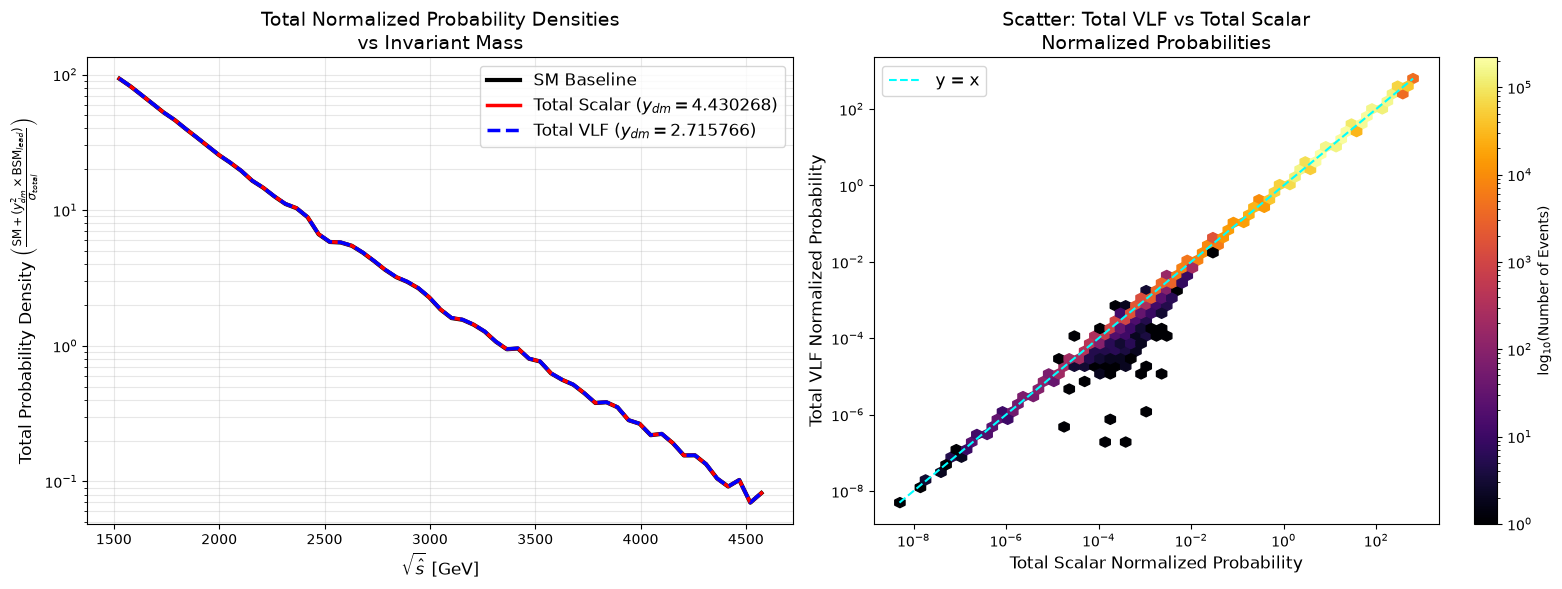


GENERATING DIAGNOSTIC PLOT: PYTHON VS LHE TRUTH


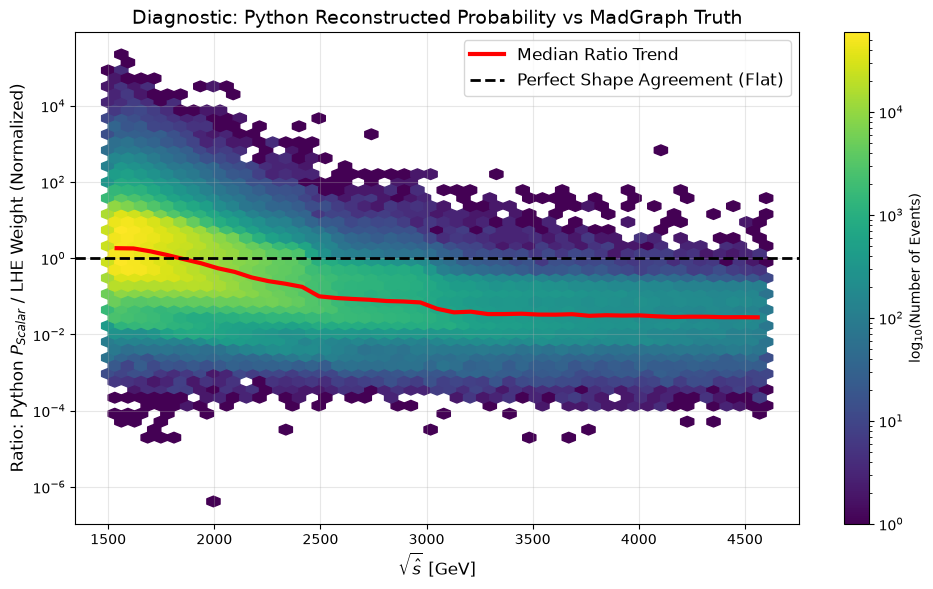

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_mtt_cut_1000_900.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

CROSS_SECTIONS = {
    "VLF":    1.2598039,  
    "Scalar": 1.2612590,  
    "Zprime": 1.2571816  
}

# ==========================================
# 2. LOAD & FILTER DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
original_len = len(df)

# Filter out negative weights (removes floating-point precision artifacts)
# This is required to safely compute logarithms and plot on log-scales
df = df[df["mg_weight"] > 0].reset_index(drop=True)

# Compute the normalized event weight w_i (sum of w_i will exactly equal 1.0)
df["w_i"] = df["mg_weight"] / df["mg_weight"].sum()

print(f"Loaded {original_len} events. Kept {len(df)} events with strictly positive weights.")
print("Computing likelihoods...")

# ==========================================
# 3. COMPUTE TOTAL NORMALIZED CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_vlf = Y_DM_CONFIG["VLF"]["y_dm"] ** Y_DM_CONFIG["VLF"]["power"]

# Apply the flavor symmetry sum for the quark initial states
flux_q = df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"]
flux_g = df["w_gg"]

# 1. Pure SM Background (using Scalar Born as reference)
df["SM_Only_Unnorm"] = (flux_q * df["ME_Born_Scalar_P0_uux_ttx"]) + (flux_g * df["ME_Born_Scalar_P2_gg_ttx"])
df["Norm_Prob_SM"] = df["SM_Only_Unnorm"] / CROSS_SECTIONS["Scalar"]

# 2. Total Scalar Model (SM Born + Scalar Finite) / Sigma_Total
df["Total_Prob_Scalar"] = (
    df["SM_Only_Unnorm"] + 
    scale_scalar * (
        (flux_q * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
        (flux_g * df["ME_Finite_Scalar_P2_gg_ttx"])
    )
) / CROSS_SECTIONS["Scalar"]

# 3. Total VLF Model (VLF Born + VLF Finite) / Sigma_Total
# Note: Re-calculating the Born part using the VLF variables to ensure strict mathematical exactness
df["Total_Prob_VLF"] = (
    (
        (flux_q * df["ME_Born_VLF_P0_uux_ttx"]) + 
        (flux_g * df["ME_Born_VLF_P2_gg_ttx"])
    ) + 
    scale_vlf * (
        (flux_q * df["ME_Finite_VLF_P0_uux_ttx"]) + 
        (flux_g * df["ME_Finite_VLF_P2_gg_ttx"])
    )
) / CROSS_SECTIONS["VLF"]

# ==========================================
# 4. PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Profile Plot vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

# Group by the bins to get the mean profile
profile_sm = df.groupby('s_hat_bin', observed=False)['Norm_Prob_SM'].mean().values
profile_scalar = df.groupby('s_hat_bin', observed=False)['Total_Prob_Scalar'].mean().values
profile_vlf = df.groupby('s_hat_bin', observed=False)['Total_Prob_VLF'].mean().values

# Plot the SM Background first
ax1.plot(bin_centers, profile_sm, label="SM Baseline", color='black', linewidth=3.0)

# Plot the Total BSM Models
ax1.plot(bin_centers, profile_scalar, label=f"Total Scalar ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_vlf, label=f"Total VLF ($y_{{dm}}={Y_DM_CONFIG['VLF']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Total Normalized Probability Densities\nvs Invariant Mass", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("Total Probability Density $\\left(\\frac{\\text{SM} + (y_{dm}^2 \\times \\text{BSM}_{lead})}{\\sigma_{total}}\\right)$", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2: Scatter Plot of Total Normalized Probabilities
# ---------------------------------------------------------
# Filter out exact zeros or negatives to safely use a log-log scale
mask = (df["Total_Prob_Scalar"] > 0) & (df["Total_Prob_VLF"] > 0) & (df['mg_weight'] >= 0)
df_scatter = df[mask]

# Density scatter plot (hexbin) for safe rendering of millions of points
hb = ax2.hexbin(df_scatter["Total_Prob_Scalar"], df_scatter["Total_Prob_VLF"], 
                xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

# Add a y = x reference line to see which model dominates
min_val = min(df_scatter["Total_Prob_Scalar"].min(), df_scatter["Total_Prob_VLF"].min())
max_val = max(df_scatter["Total_Prob_Scalar"].max(), df_scatter["Total_Prob_VLF"].max())
ax2.plot([min_val, max_val], [min_val, max_val], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: Total VLF vs Total Scalar\nNormalized Probabilities", fontsize=14)
ax2.set_xlabel("Total Scalar Normalized Probability", fontsize=12)
ax2.set_ylabel("Total VLF Normalized Probability", fontsize=12)
ax2.legend(fontsize=12)

# Add colorbar for the density
cb = fig.colorbar(hb, ax=ax2)
cb.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()
# ==========================================
# 5. DIAGNOSTIC PLOT: Python vs MadGraph Truth
# ==========================================
print("\n" + "="*60)
print("GENERATING DIAGNOSTIC PLOT: PYTHON VS LHE TRUTH")
print("="*60)

# 1. Calculate the raw ratio
df["Truth_Ratio"] = df["Total_Prob_Scalar"] / df["mg_weight"]

# 2. Normalize by the median to center the plot at 1.0 
# (We only care about the kinematic shape, not global phase-space constants)
median_ratio = df["Truth_Ratio"].median()
df["Normalized_Truth_Ratio"] = df["Truth_Ratio"] / median_ratio

# --- THE FIX: Filter non-positive values to safely plot on a log-scale ---
df_diag = df[df["Normalized_Truth_Ratio"] > 0]

# 3. Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Density scatter plot (hexbin) using the filtered dataframe (df_diag)
hb = ax.hexbin(df_diag["sqrt_s_hat"], df_diag["Normalized_Truth_Ratio"], 
               gridsize=50, cmap='viridis', bins='log', yscale='log')

# Calculate the median trend line
bins_diag = np.linspace(df_diag["sqrt_s_hat"].min(), df_diag["sqrt_s_hat"].max(), 40)
bin_centers_diag = 0.5 * (bins_diag[:-1] + bins_diag[1:])
df_diag = df_diag.copy() # Avoid SettingWithCopyWarning
df_diag['s_hat_bin_diag'] = pd.cut(df_diag['sqrt_s_hat'], bins=bins_diag)
profile_ratio = df_diag.groupby('s_hat_bin_diag', observed=False)['Normalized_Truth_Ratio'].median().values

# Plot the trend line and reference line
ax.plot(bin_centers_diag, profile_ratio, color='red', linewidth=3, label='Median Ratio Trend')
ax.axhline(1.0, color='black', linestyle='--', linewidth=2, label='Perfect Shape Agreement (Flat)')

# Formatting
ax.set_title("Diagnostic: Python Reconstructed Probability vs MadGraph Truth", fontsize=14)
ax.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax.set_ylabel("Ratio: Python $P_{Scalar}$ / LHE Weight (Normalized)", fontsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3, which='both')

cb = fig.colorbar(hb, ax=ax)
cb.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

Loading database from /home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_mtt_cut_1000_900.csv.gz...
Loaded 3155536 events.
Computing kinematics, fluxes, and probabilities...
Generating plots...


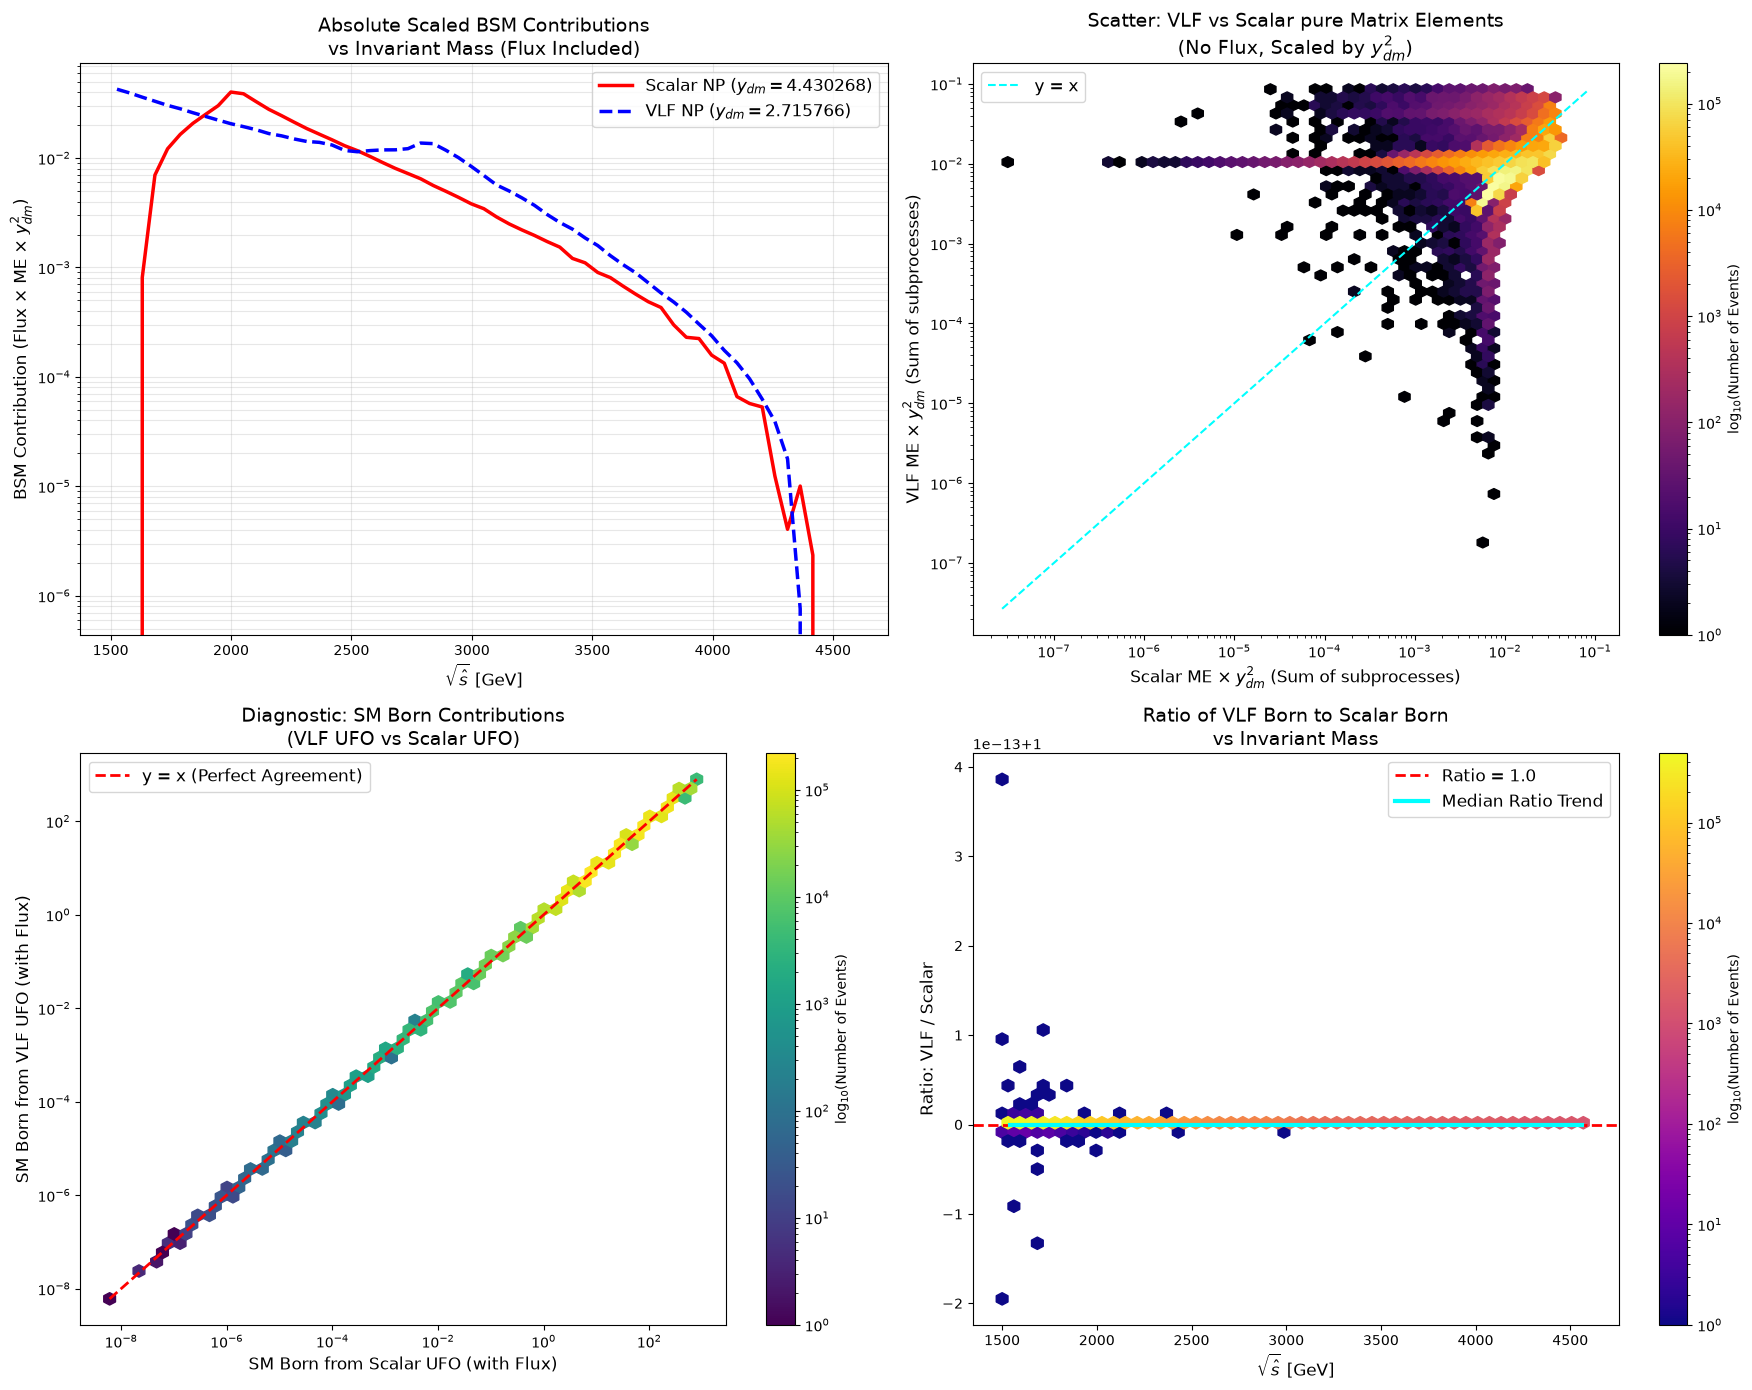

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_mtt_cut_1000_900.csv.gz"


Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading database from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} events.")
print("Computing kinematics, fluxes, and probabilities...")

# ==========================================
# 3. COMPUTE CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_vlf = Y_DM_CONFIG["VLF"]["y_dm"] ** Y_DM_CONFIG["VLF"]["power"]

# Define Fluxes for Quarks and Gluons
flux_q = df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"]
flux_g = df["w_gg"]

# --- A. BSM Contributions ---
# With Flux
df["BSM_Scalar_Scaled"] = scale_scalar * (
    (df["w_uux"] * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_Scalar_P2_gg_ttx"])
)
df["BSM_VLF_Scaled"] = scale_vlf * (
    (df["w_uux"] * df["ME_Finite_VLF_P0_uux_ttx"]) + 
    (df["w_gg"]  * df["ME_Finite_VLF_P2_gg_ttx"]) 
)

# Without Flux (Pure ME)
df["ME_Scalar_NoFlux"] = scale_scalar * (
    df["ME_Finite_Scalar_P0_uux_ttx"] + df["ME_Finite_Scalar_P2_gg_ttx"]
)
df["ME_VLF_NoFlux"] = scale_vlf * (
    df["ME_Finite_VLF_P0_uux_ttx"] + df["ME_Finite_VLF_P2_gg_ttx"]
)

# --- B. SM Born Contributions (With Flux) ---
df["SM_Born_Scalar_Flux"] = (flux_q * df["ME_Born_Scalar_P0_uux_ttx"]) + (flux_g * df["ME_Born_Scalar_P2_gg_ttx"])
df["SM_Born_VLF_Flux"] = (flux_q * df["ME_Born_VLF_P0_uux_ttx"]) + (flux_g * df["ME_Born_VLF_P2_gg_ttx"])

# Filter safely for plotting log scales on the Born calculations
mask_born = (df["SM_Born_Scalar_Flux"] > 0) & (df["SM_Born_VLF_Flux"] > 0)
df_diag_born = df[mask_born].copy()
df_diag_born["Born_Ratio"] = df_diag_born["SM_Born_VLF_Flux"] / df_diag_born["SM_Born_Scalar_Flux"]

# ==========================================
# 4. PLOTTING (2x2 Grid)
# ==========================================
print("Generating plots...")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
ax1, ax2 = axes[0][0], axes[0][1]
ax3, ax4 = axes[1][0], axes[1][1]

# ---------------------------------------------------------
# Plot 1 (Top-Left): Profile BSM Contributions vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

profile_scalar = df.groupby('s_hat_bin', observed=False)['BSM_Scalar_Scaled'].mean().values
profile_vlf = df.groupby('s_hat_bin', observed=False)['BSM_VLF_Scaled'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_vlf, label=f"VLF NP ($y_{{dm}}={Y_DM_CONFIG['VLF']['y_dm']}$)", color='blue', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Absolute Scaled BSM Contributions\nvs Invariant Mass (Flux Included)", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("BSM Contribution (Flux $\\times$ ME $\\times$ $y_{dm}^2$)", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2 (Top-Right): Scatter of Pure BSM Matrix Elements (No Flux)
# ---------------------------------------------------------
mask_me = (df["ME_Scalar_NoFlux"] > 0) & (df["ME_VLF_NoFlux"] > 0)
df_scatter = df[mask_me]

hb2 = ax2.hexbin(df_scatter["ME_Scalar_NoFlux"], df_scatter["ME_VLF_NoFlux"], 
                 xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

min_val2 = min(df_scatter["ME_Scalar_NoFlux"].min(), df_scatter["ME_VLF_NoFlux"].min())
max_val2 = max(df_scatter["ME_Scalar_NoFlux"].max(), df_scatter["ME_VLF_NoFlux"].max())
ax2.plot([min_val2, max_val2], [min_val2, max_val2], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: VLF vs Scalar pure Matrix Elements\n(No Flux, Scaled by $y_{dm}^2$)", fontsize=14)
ax2.set_xlabel("Scalar ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.set_ylabel("VLF ME $\\times \\; y_{dm}^2$ (Sum of subprocesses)", fontsize=12)
ax2.legend(fontsize=12)
cb2 = fig.colorbar(hb2, ax=ax2)
cb2.set_label('log$_{10}$(Number of Events)')

# ---------------------------------------------------------
# Plot 3 (Bottom-Left): Scatter of SM Born VLF vs SM Born Scalar
# ---------------------------------------------------------
hb3 = ax3.hexbin(df_diag_born["SM_Born_Scalar_Flux"], df_diag_born["SM_Born_VLF_Flux"], 
                 xscale='log', yscale='log', gridsize=50, cmap='viridis', bins='log')

min_val3 = min(df_diag_born["SM_Born_Scalar_Flux"].min(), df_diag_born["SM_Born_VLF_Flux"].min())
max_val3 = max(df_diag_born["SM_Born_Scalar_Flux"].max(), df_diag_born["SM_Born_VLF_Flux"].max())
ax3.plot([min_val3, max_val3], [min_val3, max_val3], color='red', linestyle='--', linewidth=2, label='y = x (Perfect Agreement)')

ax3.set_title("Diagnostic: SM Born Contributions\n(VLF UFO vs Scalar UFO)", fontsize=14)
ax3.set_xlabel("SM Born from Scalar UFO (with Flux)", fontsize=12)
ax3.set_ylabel("SM Born from VLF UFO (with Flux)", fontsize=12)
ax3.legend(fontsize=12)
cb3 = fig.colorbar(hb3, ax=ax3)
cb3.set_label('log$_{10}$(Number of Events)')

# ---------------------------------------------------------
# Plot 4 (Bottom-Right): Ratio of Borns vs Invariant Mass
# ---------------------------------------------------------
hb4 = ax4.hexbin(df_diag_born["sqrt_s_hat"], df_diag_born["Born_Ratio"], 
                 gridsize=50, cmap='plasma', bins='log')

ax4.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Ratio = 1.0')

bins_diag = np.linspace(df_diag_born["sqrt_s_hat"].min(), df_diag_born["sqrt_s_hat"].max(), 40)
bin_centers_diag = 0.5 * (bins_diag[:-1] + bins_diag[1:])
df_diag_born['s_hat_bin_diag'] = pd.cut(df_diag_born['sqrt_s_hat'], bins=bins_diag)
profile_ratio = df_diag_born.groupby('s_hat_bin_diag', observed=False)['Born_Ratio'].median().values

ax4.plot(bin_centers_diag, profile_ratio, color='cyan', linewidth=3, label='Median Ratio Trend')

ax4.set_title("Ratio of VLF Born to Scalar Born\nvs Invariant Mass", fontsize=14)
ax4.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax4.set_ylabel("Ratio: VLF / Scalar", fontsize=12)
ax4.legend(fontsize=12)
cb4 = fig.colorbar(hb4, ax=ax4)
cb4.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

Looking for files matching: /home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_*.csv.gz
Found 3 files. Loading and concatenating...
Loaded a total of 11911179 events.
Clipping unphysical PDF fluxes, computing kinematics and probabilities...
Generating plots...


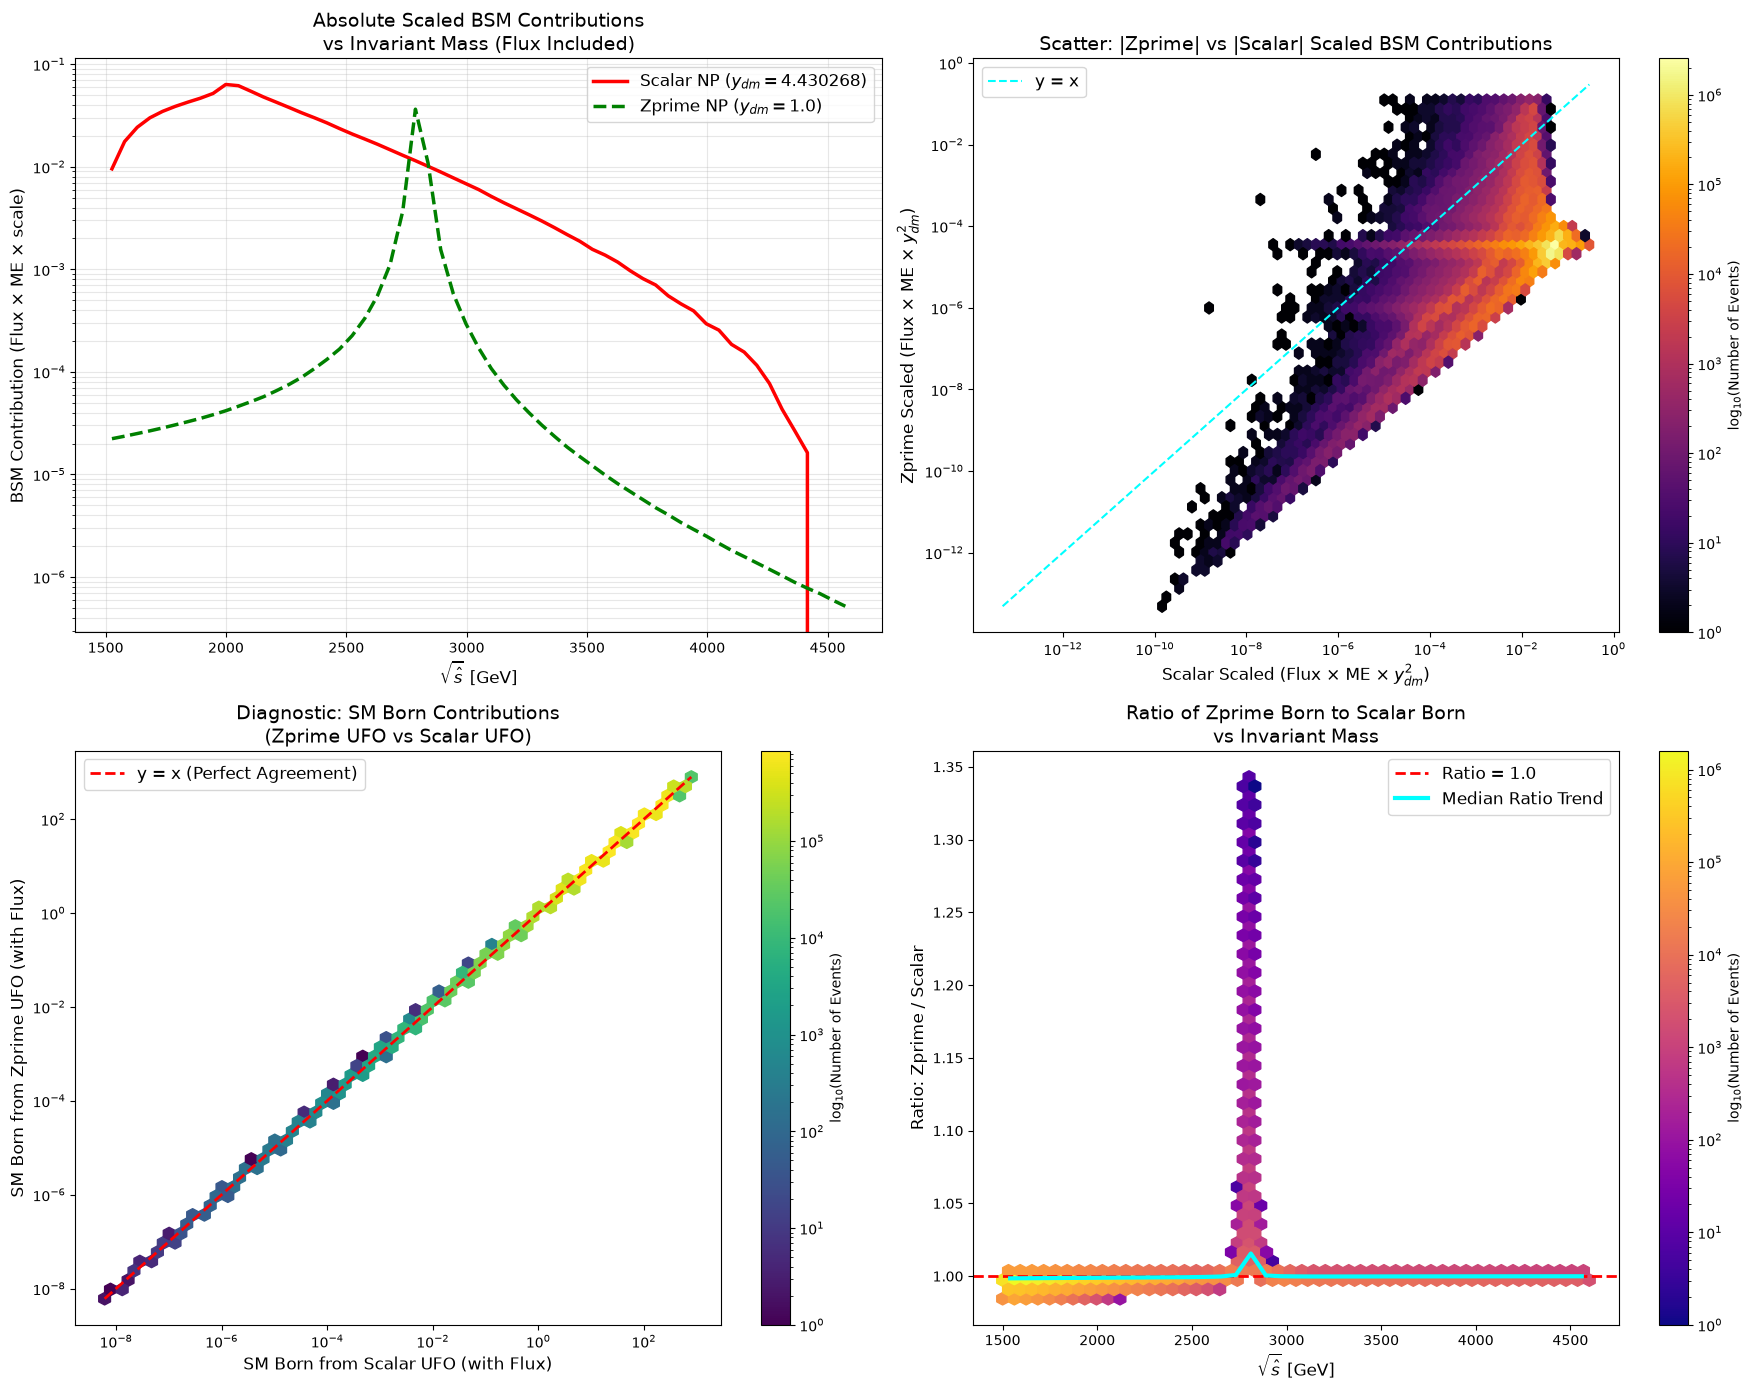

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import gc

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV_PATTERN = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_*.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

# ==========================================
# 2. LOAD DATA (USING GLOB)
# ==========================================
print(f"Looking for files matching: {INPUT_CSV_PATTERN}")
csv_files = sorted(list(glob.glob(INPUT_CSV_PATTERN)))

if not csv_files:
    raise FileNotFoundError(f"No files found matching the pattern.")

print(f"Found {len(csv_files)} files. Loading and concatenating...")

dataframes = []
for file_path in csv_files:
    df_temp = pd.read_csv(file_path)
    dataframes.append(df_temp)

df = pd.concat(dataframes, ignore_index=True)
del dataframes
gc.collect()

print(f"Loaded a total of {len(df)} events.")
print("Clipping unphysical PDF fluxes, computing kinematics and probabilities...")

# ==========================================
# 3. COMPUTE CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_zprime = Y_DM_CONFIG["Zprime"]["y_dm"] ** Y_DM_CONFIG["Zprime"]["power"]

# ---------------------------------------------------------
# THE FIX: Component-by-Component Flux Clipping
# ---------------------------------------------------------
# We clip the native columns to exactly zero to ensure no negative 
# PDF artifacts propagate into any downstream sum or product.
for flavor in ["w_uux", "w_ddx", "w_ccx", "w_ssx", "w_bbx", "w_gg"]:
    if flavor in df.columns:
        df[flavor] = np.clip(df[flavor], a_min=0.0, a_max=None)

# Define Fluxes safely using the clipped columns
flux_q_sym = df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"]
flux_g = df["w_gg"]

# --- A. BSM Contributions ---
# With Flux
df["BSM_Scalar_Scaled"] = scale_scalar * (
    (flux_q_sym * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    (flux_g     * df["ME_Finite_Scalar_P2_gg_ttx"])
)

df["BSM_Zprime_Scaled"] = scale_zprime * (
    (df["w_uux"] * df["ME_Born_NP_Zprime_P2_uux_ttx"]) + 
    (df["w_ddx"] * df["ME_Born_NP_Zprime_P3_ddx_ttx"]) + 
    (flux_g      * df["ME_Born_NP_Zprime_P0_gg_ttx"]) 
)

# Without Flux (Pure ME)
df["ME_Scalar_NoFlux"] = scale_scalar * (
    df["ME_Finite_Scalar_P0_uux_ttx"] + df["ME_Finite_Scalar_P2_gg_ttx"]
)

df["ME_Zprime_NoFlux"] = scale_zprime * (
    df["ME_Born_NP_Zprime_P2_uux_ttx"] + 
    df["ME_Born_NP_Zprime_P3_ddx_ttx"] + 
    df["ME_Born_NP_Zprime_P0_gg_ttx"]
)

# --- B. SM Born Contributions (With Flux) ---
df["SM_Born_Scalar_Flux"] = (flux_q_sym * df["ME_Born_Scalar_P0_uux_ttx"]) + (flux_g * df["ME_Born_Scalar_P2_gg_ttx"])

df["SM_Born_Zprime_Flux"] = (
    (df["w_uux"] * df["ME_Born_SM_Zprime_P2_uux_ttx"]) + 
    (df["w_ddx"] * df["ME_Born_SM_Zprime_P3_ddx_ttx"]) + 
    (flux_g      * df["ME_Born_SM_Zprime_P0_gg_ttx"])
)

# Filter safely for plotting log scales on the Born calculations
mask_born = (df["SM_Born_Scalar_Flux"] > 0) & (df["SM_Born_Zprime_Flux"] > 0)
df_diag_born = df[mask_born].copy()
df_diag_born["Born_Ratio"] = df_diag_born["SM_Born_Zprime_Flux"] / df_diag_born["SM_Born_Scalar_Flux"]

# ==========================================
# 4. PLOTTING (2x2 Grid)
# ==========================================
print("Generating plots...")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
ax1, ax2 = axes[0][0], axes[0][1]
ax3, ax4 = axes[1][0], axes[1][1]

# ---------------------------------------------------------
# Plot 1 (Top-Left): Profile BSM Contributions vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

profile_scalar = df.groupby('s_hat_bin', observed=False)['BSM_Scalar_Scaled'].mean().values
profile_zprime = df.groupby('s_hat_bin', observed=False)['BSM_Zprime_Scaled'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_zprime, label=f"Zprime NP ($y_{{dm}}={Y_DM_CONFIG['Zprime']['y_dm']}$)", color='green', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Absolute Scaled BSM Contributions\nvs Invariant Mass (Flux Included)", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("BSM Contribution (Flux $\\times$ ME $\\times$ scale)", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2 (Top-Right): Scatter of Pure BSM Matrix Elements
# ---------------------------------------------------------
# Taking absolute values to prevent log-scale warnings from interference terms
mask_me = (df["BSM_Scalar_Scaled"].abs() > 0) & (df["BSM_Zprime_Scaled"].abs() > 0)
df_scatter = df[mask_me]

hb2 = ax2.hexbin(df_scatter["BSM_Scalar_Scaled"].abs(), df_scatter["BSM_Zprime_Scaled"].abs(), 
                 xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

min_val2 = min(df_scatter["BSM_Scalar_Scaled"].abs().min(), df_scatter["BSM_Zprime_Scaled"].abs().min())
max_val2 = max(df_scatter["BSM_Scalar_Scaled"].abs().max(), df_scatter["BSM_Zprime_Scaled"].abs().max())
ax2.plot([min_val2, max_val2], [min_val2, max_val2], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: |Zprime| vs |Scalar| Scaled BSM Contributions", fontsize=14)
ax2.set_xlabel("Scalar Scaled (Flux $\\times$ ME $\\times \\; y_{dm}^2$)", fontsize=12)
ax2.set_ylabel("Zprime Scaled (Flux $\\times$ ME $\\times \\; y_{dm}^2$)", fontsize=12)
ax2.legend(fontsize=12)
cb2 = fig.colorbar(hb2, ax=ax2)
cb2.set_label('log$_{10}$(Number of Events)')

# ---------------------------------------------------------
# Plot 3 (Bottom-Left): Scatter of SM Born Zprime vs SM Born Scalar
# ---------------------------------------------------------
hb3 = ax3.hexbin(df_diag_born["SM_Born_Scalar_Flux"], df_diag_born["SM_Born_Zprime_Flux"], 
                 xscale='log', yscale='log', gridsize=50, cmap='viridis', bins='log')

min_val3 = min(df_diag_born["SM_Born_Scalar_Flux"].min(), df_diag_born["SM_Born_Zprime_Flux"].min())
max_val3 = max(df_diag_born["SM_Born_Scalar_Flux"].max(), df_diag_born["SM_Born_Zprime_Flux"].max())
ax3.plot([min_val3, max_val3], [min_val3, max_val3], color='red', linestyle='--', linewidth=2, label='y = x (Perfect Agreement)')

ax3.set_title("Diagnostic: SM Born Contributions\n(Zprime UFO vs Scalar UFO)", fontsize=14)
ax3.set_xlabel("SM Born from Scalar UFO (with Flux)", fontsize=12)
ax3.set_ylabel("SM Born from Zprime UFO (with Flux)", fontsize=12)
ax3.legend(fontsize=12)
cb3 = fig.colorbar(hb3, ax=ax3)
cb3.set_label('log$_{10}$(Number of Events)')

# ---------------------------------------------------------
# Plot 4 (Bottom-Right): Ratio of Borns vs Invariant Mass
# ---------------------------------------------------------
hb4 = ax4.hexbin(df_diag_born["sqrt_s_hat"], df_diag_born["Born_Ratio"], 
                 gridsize=50, cmap='plasma', bins='log')

ax4.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Ratio = 1.0')

bins_diag = np.linspace(df_diag_born["sqrt_s_hat"].min(), df_diag_born["sqrt_s_hat"].max(), 40)
bin_centers_diag = 0.5 * (bins_diag[:-1] + bins_diag[1:])
df_diag_born['s_hat_bin_diag'] = pd.cut(df_diag_born['sqrt_s_hat'], bins=bins_diag)
profile_ratio = df_diag_born.groupby('s_hat_bin_diag', observed=False)['Born_Ratio'].median().values

ax4.plot(bin_centers_diag, profile_ratio, color='cyan', linewidth=3, label='Median Ratio Trend')

ax4.set_title("Ratio of Zprime Born to Scalar Born\nvs Invariant Mass", fontsize=14)
ax4.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax4.set_ylabel("Ratio: Zprime / Scalar", fontsize=12)
ax4.legend(fontsize=12)
cb4 = fig.colorbar(hb4, ax=ax4)
cb4.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

Looking for files matching: /home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_*.csv.gz
Found 3 files. Loading and concatenating...
Loaded a total of 11911179 events.
Clipping unphysical PDF fluxes, computing kinematics and probabilities...
Generating plots...


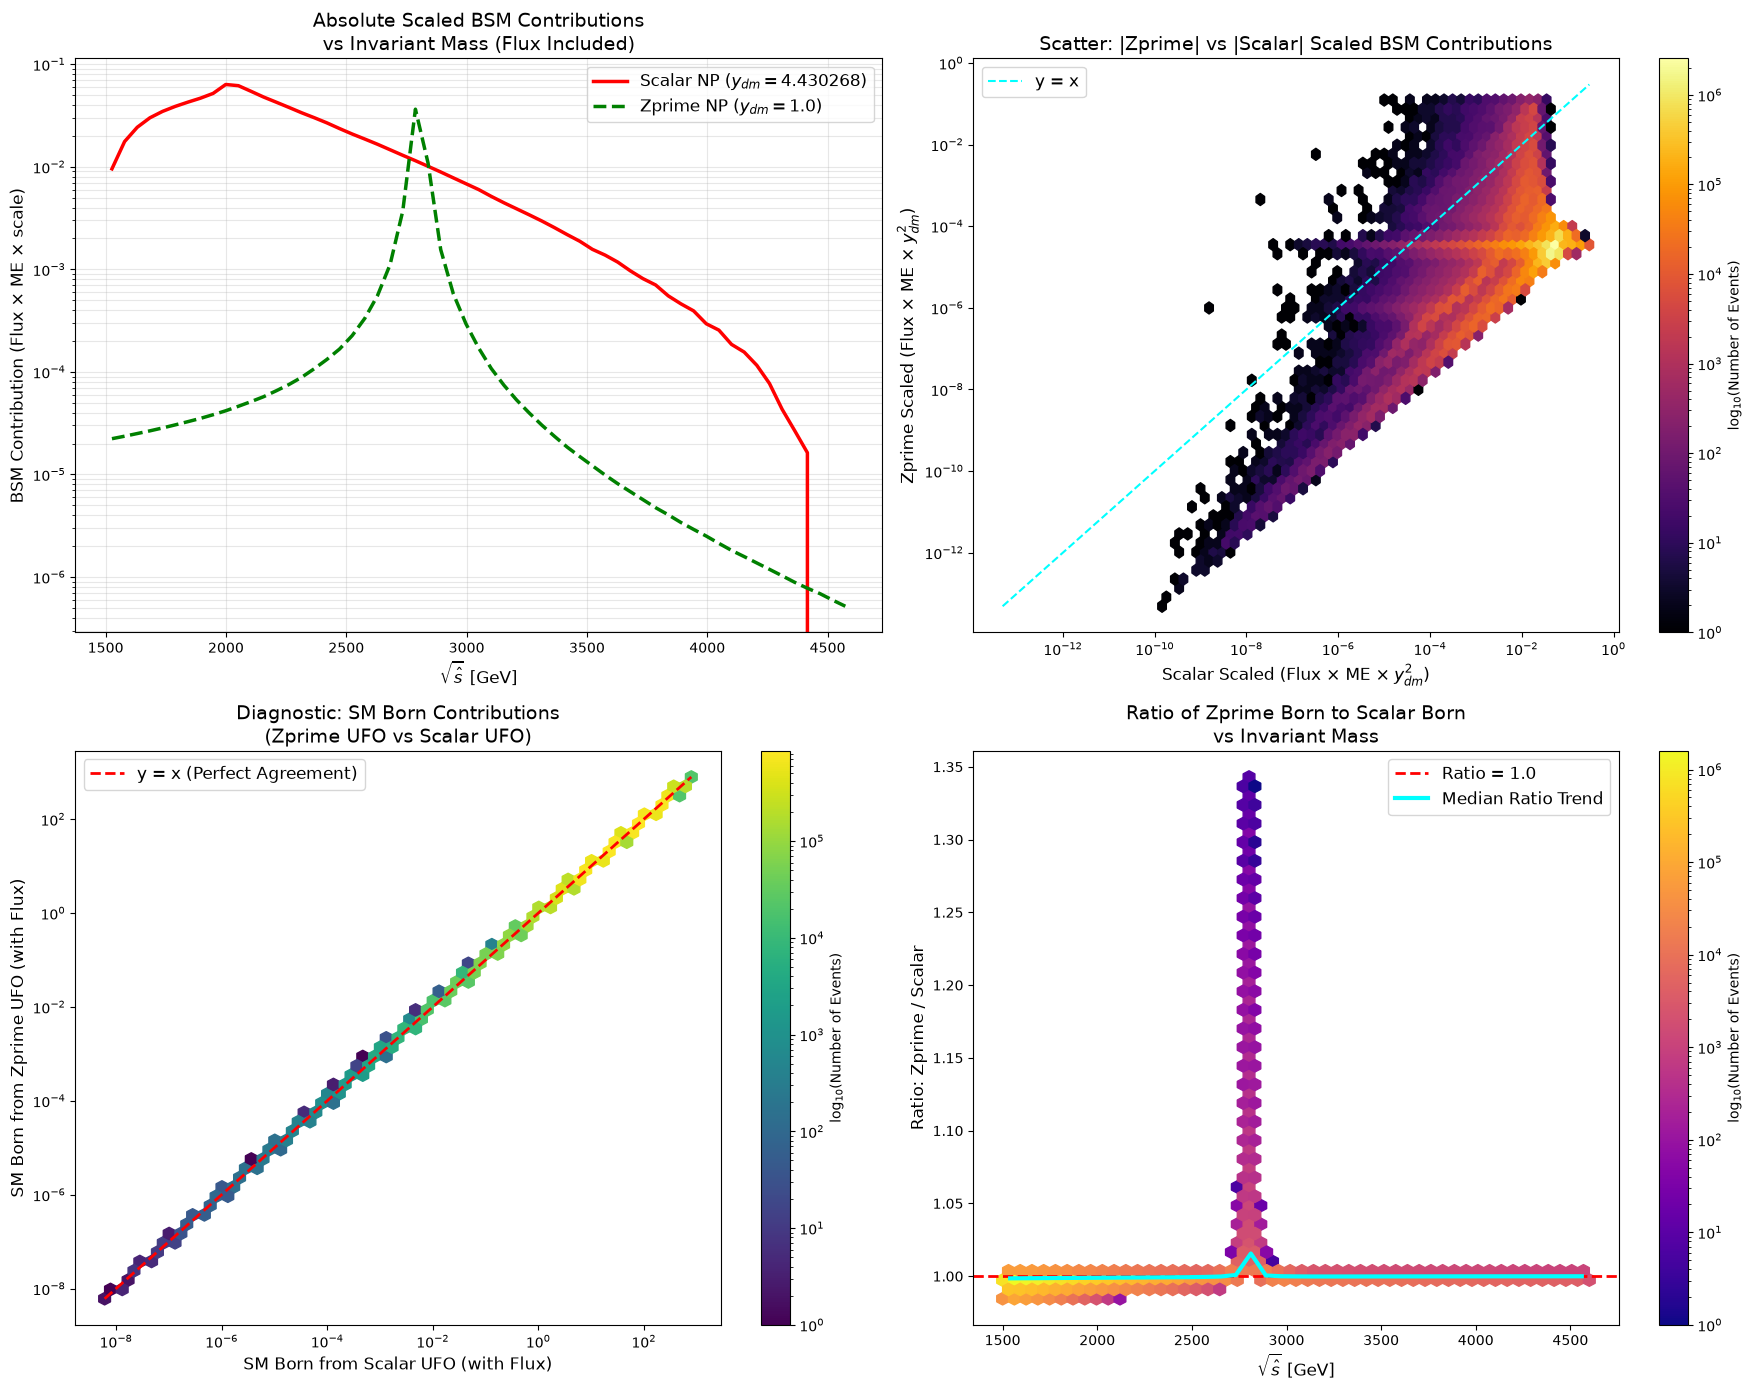

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import gc

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_CSV_PATTERN = "/home/vinicius/UnfoldingBSMttbar/MatrixElements/Weighted/Matrix_AllModels_*.csv.gz"

Y_DM_CONFIG = {
    "VLF":    {"y_dm": 2.715766, "power": 2}, 
    "Scalar": {"y_dm": 4.430268, "power": 2},
    "Zprime": {"y_dm": 1.0, "power": 2}  
}

# ==========================================
# 2. LOAD DATA (USING GLOB)
# ==========================================
print(f"Looking for files matching: {INPUT_CSV_PATTERN}")
csv_files = sorted(list(glob.glob(INPUT_CSV_PATTERN)))

if not csv_files:
    raise FileNotFoundError(f"No files found matching the pattern.")

print(f"Found {len(csv_files)} files. Loading and concatenating...")

dataframes = []
for file_path in csv_files:
    df_temp = pd.read_csv(file_path)
    dataframes.append(df_temp)

df = pd.concat(dataframes, ignore_index=True)
del dataframes
gc.collect()

print(f"Loaded a total of {len(df)} events.")
print("Clipping unphysical PDF fluxes, computing kinematics and probabilities...")

# ==========================================
# 3. COMPUTE CONTRIBUTIONS
# ==========================================
df["sqrt_s_hat"] = np.sqrt(df["s_hat"])

scale_scalar = Y_DM_CONFIG["Scalar"]["y_dm"] ** Y_DM_CONFIG["Scalar"]["power"]
scale_zprime = Y_DM_CONFIG["Zprime"]["y_dm"] ** Y_DM_CONFIG["Zprime"]["power"]

# ---------------------------------------------------------
# THE FIX: Component-by-Component Flux Clipping
# ---------------------------------------------------------
# We clip the native columns to exactly zero to ensure no negative 
# PDF artifacts propagate into any downstream sum or product.
for flavor in ["w_uux", "w_ddx", "w_ccx", "w_ssx", "w_bbx", "w_gg"]:
    if flavor in df.columns:
        df[flavor] = np.clip(df[flavor], a_min=0.0, a_max=None)

# Define Fluxes safely using the clipped columns
flux_q_sym = df["w_uux"] + df["w_ddx"] + df["w_ccx"] + df["w_ssx"] + df["w_bbx"]
flux_g = df["w_gg"]

# --- A. BSM Contributions ---
# With Flux
df["BSM_Scalar_Scaled"] = scale_scalar * (
    (flux_q_sym * df["ME_Finite_Scalar_P0_uux_ttx"]) + 
    (flux_g     * df["ME_Finite_Scalar_P2_gg_ttx"])
)

df["BSM_Zprime_Scaled"] = scale_zprime * (
    (df["w_uux"] * df["ME_Born_NP_Zprime_P2_uux_ttx"]) + 
    (df["w_ddx"] * df["ME_Born_NP_Zprime_P3_ddx_ttx"]) + 
    (flux_g      * df["ME_Born_NP_Zprime_P0_gg_ttx"]) 
)

# Without Flux (Pure ME)
df["ME_Scalar_NoFlux"] = scale_scalar * (
    df["ME_Finite_Scalar_P0_uux_ttx"] + df["ME_Finite_Scalar_P2_gg_ttx"]
)

df["ME_Zprime_NoFlux"] = scale_zprime * (
    df["ME_Born_NP_Zprime_P2_uux_ttx"] + 
    df["ME_Born_NP_Zprime_P3_ddx_ttx"] + 
    df["ME_Born_NP_Zprime_P0_gg_ttx"]
)

# --- B. SM Born Contributions (With Flux) ---
df["SM_Born_Scalar_Flux"] = (flux_q_sym * df["ME_Born_Scalar_P0_uux_ttx"]) + (flux_g * df["ME_Born_Scalar_P2_gg_ttx"])

df["SM_Born_Zprime_Flux"] = (
    (df["w_uux"] * df["ME_Born_SM_Zprime_P2_uux_ttx"]) + 
    (df["w_ddx"] * df["ME_Born_SM_Zprime_P3_ddx_ttx"]) + 
    (flux_g      * df["ME_Born_SM_Zprime_P0_gg_ttx"])
)

# Filter safely for plotting log scales on the Born calculations
mask_born = (df["SM_Born_Scalar_Flux"] > 0) & (df["SM_Born_Zprime_Flux"] > 0)
df_diag_born = df[mask_born].copy()
df_diag_born["Born_Ratio"] = df_diag_born["SM_Born_Zprime_Flux"] / df_diag_born["SM_Born_Scalar_Flux"]

# ==========================================
# 4. PLOTTING (2x2 Grid)
# ==========================================
print("Generating plots...")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
ax1, ax2 = axes[0][0], axes[0][1]
ax3, ax4 = axes[1][0], axes[1][1]

# ---------------------------------------------------------
# Plot 1 (Top-Left): Profile BSM Contributions vs Invariant Mass
# ---------------------------------------------------------
bins = np.linspace(df["sqrt_s_hat"].min(), df["sqrt_s_hat"].max(), 60)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
df['s_hat_bin'] = pd.cut(df['sqrt_s_hat'], bins=bins)

profile_scalar = df.groupby('s_hat_bin', observed=False)['BSM_Scalar_Scaled'].mean().values
profile_zprime = df.groupby('s_hat_bin', observed=False)['BSM_Zprime_Scaled'].mean().values

ax1.plot(bin_centers, profile_scalar, label=f"Scalar NP ($y_{{dm}}={Y_DM_CONFIG['Scalar']['y_dm']}$)", color='red', linewidth=2.5)
ax1.plot(bin_centers, profile_zprime, label=f"Zprime NP ($y_{{dm}}={Y_DM_CONFIG['Zprime']['y_dm']}$)", color='green', linewidth=2.5, linestyle='--')

ax1.set_yscale('log')
ax1.set_title("Absolute Scaled BSM Contributions\nvs Invariant Mass (Flux Included)", fontsize=14)
ax1.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax1.set_ylabel("BSM Contribution (Flux $\\times$ ME $\\times$ scale)", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3, which='both')

# ---------------------------------------------------------
# Plot 2 (Top-Right): Scatter of Pure BSM Matrix Elements
# ---------------------------------------------------------
# Taking absolute values to prevent log-scale warnings from interference terms
mask_me = (df["BSM_Scalar_Scaled"].abs() > 0) & (df["BSM_Zprime_Scaled"].abs() > 0)
df_scatter = df[mask_me]

hb2 = ax2.hexbin(df_scatter["BSM_Scalar_Scaled"].abs(), df_scatter["BSM_Zprime_Scaled"].abs(), 
                 xscale='log', yscale='log', gridsize=50, cmap='inferno', bins='log')

min_val2 = min(df_scatter["BSM_Scalar_Scaled"].abs().min(), df_scatter["BSM_Zprime_Scaled"].abs().min())
max_val2 = max(df_scatter["BSM_Scalar_Scaled"].abs().max(), df_scatter["BSM_Zprime_Scaled"].abs().max())
ax2.plot([min_val2, max_val2], [min_val2, max_val2], color='cyan', linestyle='--', linewidth=1.5, label='y = x')

ax2.set_title("Scatter: |Zprime| vs |Scalar| Scaled BSM Contributions", fontsize=14)
ax2.set_xlabel("Scalar Scaled (Flux $\\times$ ME $\\times \\; y_{dm}^2$)", fontsize=12)
ax2.set_ylabel("Zprime Scaled (Flux $\\times$ ME $\\times \\; y_{dm}^2$)", fontsize=12)
ax2.legend(fontsize=12)
cb2 = fig.colorbar(hb2, ax=ax2)
cb2.set_label('log$_{10}$(Number of Events)')

# ---------------------------------------------------------
# Plot 3 (Bottom-Left): Scatter of SM Born Zprime vs SM Born Scalar
# ---------------------------------------------------------
hb3 = ax3.hexbin(df_diag_born["SM_Born_Scalar_Flux"], df_diag_born["SM_Born_Zprime_Flux"], 
                 xscale='log', yscale='log', gridsize=50, cmap='viridis', bins='log')

min_val3 = min(df_diag_born["SM_Born_Scalar_Flux"].min(), df_diag_born["SM_Born_Zprime_Flux"].min())
max_val3 = max(df_diag_born["SM_Born_Scalar_Flux"].max(), df_diag_born["SM_Born_Zprime_Flux"].max())
ax3.plot([min_val3, max_val3], [min_val3, max_val3], color='red', linestyle='--', linewidth=2, label='y = x (Perfect Agreement)')

ax3.set_title("Diagnostic: SM Born Contributions\n(Zprime UFO vs Scalar UFO)", fontsize=14)
ax3.set_xlabel("SM Born from Scalar UFO (with Flux)", fontsize=12)
ax3.set_ylabel("SM Born from Zprime UFO (with Flux)", fontsize=12)
ax3.legend(fontsize=12)
cb3 = fig.colorbar(hb3, ax=ax3)
cb3.set_label('log$_{10}$(Number of Events)')

# ---------------------------------------------------------
# Plot 4 (Bottom-Right): Ratio of Borns vs Invariant Mass
# ---------------------------------------------------------
hb4 = ax4.hexbin(df_diag_born["sqrt_s_hat"], df_diag_born["Born_Ratio"], 
                 gridsize=50, cmap='plasma', bins='log')

ax4.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Ratio = 1.0')

bins_diag = np.linspace(df_diag_born["sqrt_s_hat"].min(), df_diag_born["sqrt_s_hat"].max(), 40)
bin_centers_diag = 0.5 * (bins_diag[:-1] + bins_diag[1:])
df_diag_born['s_hat_bin_diag'] = pd.cut(df_diag_born['sqrt_s_hat'], bins=bins_diag)
profile_ratio = df_diag_born.groupby('s_hat_bin_diag', observed=False)['Born_Ratio'].median().values

ax4.plot(bin_centers_diag, profile_ratio, color='cyan', linewidth=3, label='Median Ratio Trend')

ax4.set_title("Ratio of Zprime Born to Scalar Born\nvs Invariant Mass", fontsize=14)
ax4.set_xlabel("$\\sqrt{\\hat{s}}$ [GeV]", fontsize=12)
ax4.set_ylabel("Ratio: Zprime / Scalar", fontsize=12)
ax4.legend(fontsize=12)
cb4 = fig.colorbar(hb4, ax=ax4)
cb4.set_label('log$_{10}$(Number of Events)')

plt.tight_layout()
plt.show()

In [14]:
import sys
import os
import glob
import importlib.util
import numpy as np
import pandas as pd
import pylhe
from tqdm import tqdm

# --- LHAPDF Path Setup ---
# Replace with your actual LHAPDF installation path if different
sys.path.append("/home/vinicius/MG5/HEPTools/lhapdf6_py3/lib/python3.14/dist-packages")
import lhapdf

# ==========================================
# 1. CONFIGURATION & MODEL REGISTRY SETUP
# ==========================================
E_BEAM = 6500.0    # Beam energy in GeV (e.g., 6500 for 13 TeV LHC)
PDF_NAME = 244600  # Must match the PDF set used in your MG5 event generation

# Fixed Renormalization & Factorization Scale 
MU_F  = 91.188     # Factorization scale in GeV (used ONLY for LHAPDF parton densities)
MU_R  = 91.188    # Renormalization scale in GeV (used for LHAPDF alpha_s)
MU_R2 = MU_R**2    # Renormalization scale squared in GeV^2 (used for MadLoop virtuals)   # Scale squared in GeV^2 (used for MadLoop virtuals)

# Define absolute root paths for all 3 model hypotheses
MODEL_ROOTS = {
    "VLF":    os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/UV_BSM/MatrixElements/SubProcesses"),
    "Scalar": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/SMS_1_loop/MatrixElements/SubProcesses"),
    "Zprime": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/z_prime/test_nlo_MatrixElements/SubProcesses")
}

# Define production channels (using P1_ indexing for Zprime as confirmed earlier)
MODEL_CHANNELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": [
        "P2_uux_ttx", 
        "P3_ddx_ttx", 
        "P0_gg_ttx"
    ]
}

# Map MadGraph directory prefixes to their corresponding PDG quark IDs for PDF lookup
PDG_MAP = {
    "uux": 2,  # Up
    "ddx": 1,  # Down
    "ssx": 3,  # Strange
    "ccx": 4,  # Charm
    "bbx": 5   # Bottom
}

# ==========================================
# 2. UNIVERSAL LIBRARY LOADER & INITIALIZER
# ==========================================

def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p
def init_model_card(module, subproc_path, module_label):
    """Dynamically detects and calls the correct Fortran initialization routine."""
    card_path = os.path.abspath(os.path.join(subproc_path, "..", "..", "Cards", "param_card.dat"))
    if not os.path.exists(card_path):
        raise FileNotFoundError(f"[{module_label}] Could not find parameter card at: {card_path}")
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        mod_attrs = dir(module)
        lo_init = [a for a in mod_attrs if a.endswith('initialisemodel')]
        nlo_init = [a for a in mod_attrs if 'initialise' in a and not a.endswith('initialisemodel')]
        
        if lo_init:
            getattr(module, lo_init[0])(card_path)
        elif nlo_init:
            getattr(module, nlo_init[0])(card_path)
        else:
            raise AttributeError(f"[{module_label}] No valid initialization subroutine found!")
    finally:
        os.chdir(original_cwd)

def load_all_models(roots_dict, channels_dict):
    """Loads and compiles all matrix_*.so libraries into a unified dictionary registry."""
    registry = {}
    print("Loading Matrix Element Libraries...\n" + "="*50)
    for model_name, root_dir in roots_dict.items():
        print(f" -> Loading Model: [{model_name}]")
        registry[model_name] = {}
        for channel in channels_dict[model_name]:
            subproc_path = os.path.join(root_dir, channel)
            if subproc_path not in sys.path:
                sys.path.append(subproc_path)
            
            so_files = glob.glob(os.path.join(subproc_path, f"*matrix_{model_name}*.so")) or \
                       glob.glob(os.path.join(subproc_path, "*matrix*.so"))
            if not so_files:
                raise FileNotFoundError(f"No compiled .so library found in {subproc_path}")
            
            so_path = so_files[0]
            lib_name = os.path.basename(so_path).split(".")[0]  # Strip architecture tags
            
            spec = importlib.util.spec_from_file_location(lib_name, so_path)
            mod = importlib.util.module_from_spec(spec)
            sys.modules[lib_name] = mod
            spec.loader.exec_module(mod)
            
            init_model_card(mod, subproc_path, f"{model_name} | {channel}")
            registry[model_name][channel] = {
                "module": mod,
                "path": subproc_path
            }
            print(f"    [✓] {channel}")
    print("="*50 + "\n")
    return registry

# Initialize global model registry
models = load_all_models(MODEL_ROOTS, MODEL_CHANNELS)

Loading Matrix Element Libraries...
 -> Loading Model: [VLF]
    [✓] P0_uux_ttx
    [✓] P2_gg_ttx
 -> Loading Model: [Scalar]
    [✓] P0_uux_ttx
    [✓] P2_gg_ttx
 -> Loading Model: [Zprime]
    [✓] P2_uux_ttx
    [✓] P3_ddx_ttx
    [✓] P0_gg_ttx



In [23]:
import sys
import os
import glob
import importlib.util
import numpy as np
import pandas as pd
import lhapdf

# ==========================================
# 1. DEFINE YOUR SPECIFIC PHASE SPACE POINT
# ==========================================
# Format: [E, px, py, pz] in GeV
# Center-of-mass energy sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV
p_user_lab = [
    [0.5000000E+03,  0.0000000E+00,  0.0000000E+00,  0.5000000E+03],
    [0.5000000E+03,  0.0000000E+00,  0.0000000E+00, -0.5000000E+03],
    [0.5000000E+03,  0.1041545E+03,  0.4176826E+03, -0.1873741E+03],
    [0.5000000E+03, -0.1041545E+03, -0.4176826E+03,  0.1873741E+03]
]

#p_user_lab = [
 #   [0.5000000E+03,  0.0000000E+00,   0.0000000E+00,  0.5000000E+03],
  #  [0.5000000E+03,  0.0000000E+00,   0.0000000E+00, -0.5000000E+03],
   # [0.5000000E+03, -0.1773983e-306, -0.1736952E+03, -0.4361720E+03],
   # [0.5000000E+03,  0.1773983e-306,  0.1736952E+03,  0.4361720E+03]
#]
p_user_lab = [
    [1.1531302741E+02,  0.0000000000E+00,  0.0000000000E+00,  1.1531302741E+02],  # ubar (initial)
    [5.1757384408E+03,  0.0000000000E+00,  0.0000000000E+00, -5.1757384408E+03],  # u    (initial)
    [5.0065023091E+02, -3.2209408283E+02, -1.8605514968E+02, -2.8758570338E+02],  # t    (final)
    [4.7904012373E+03,  3.2209408283E+02,  1.8605514968E+02, -4.7728397100E+03]   # tbar (final)
]

# Transpose array to match Fortran memory layout (4 x N_particles)
def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p

p_fortran = invert_momenta(p_user_lab)

# ==========================================
# 2. DYNAMIC COMPONENT UNPACKER
# ==========================================
def eval_full_me_components(module_dict, model_name, p_fortran, alphas, scale2, nhel=-1):
    mod = module_dict["module"]
    subproc_path = module_dict["path"]
    mod_attrs = dir(mod)
    
    lo_eval = [a for a in mod_attrs if a.endswith('get_value')]
    nlo_eval = [a for a in mod_attrs if a.endswith('get_me')]
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        
        # --- CASE 1: LEADING ORDER (StandAlone get_value) ---
        if lo_eval:
            val = getattr(mod, lo_eval[0])(p_fortran, alphas, nhel)
            val_list = [float(x) for x in np.ravel(val)]
            born_val = val_list[0] if len(val_list) > 0 else 0.0
            
            return {
                "Type": "LO (Tree)",
                "Born (|M0|^2)": born_val,
                "Finite 1-Loop": 0.0,
                "Single Pole (1/eps)": 0.0,
                "Double Pole (1/eps^2)": 0.0,
                "MadLoop Code": "N/A",
                "Raw Array": val_list
            }
            
        # --- CASE 2: NEXT-TO-LEADING ORDER / LOOP (get_me) ---
        elif nlo_eval:
            res, ret_code = getattr(mod, nlo_eval[0])(p_fortran, alphas, scale2, nhel)
            res_flat = np.ravel(res)
            
            print(f"Debug Raw Array ({model_name} / {os.path.basename(subproc_path)}): {res_flat.tolist()}")
            
            # ---------------------------------------------------------
            # BRANCH 1: Z-PRIME MODEL SPECIFIC LOGIC
            # ---------------------------------------------------------
            if "z_prime" in model_name.lower() or "zprime" in model_name.lower():
                
                # Z-prime CASE A: 2-element array (gg subprocess)
                if res_flat.size == 2:
                    born_val   = float(res_flat[0]) # Total / SM Born
                    finite_val = 0 # Z' contribution
                    pole1_val  = 0.0
                    pole2_val  = 0.0
                    m_type     = "Z' NLO (gg, 2-comp)"

                # Z-prime CASE B: 4-element array (uux / ddx subprocesses)
                # Layout: [Total, Pure Z', Interference, Pure SM]
                elif res_flat.size == 4:
                    born_val   = float(res_flat[3]) # Pure SM Born
                    finite_val = float(res_flat[1]) # Pure Z'
                    pole1_val  = float(res_flat[2]) # Interference stored in Single Pole column
                    pole2_val  = 0.0
                    m_type     = "Z' NLO (qqbar, 4-comp)"

                else:
                    born_val   = float(res_flat[0]) if len(res_flat) > 0 else 0.0
                    finite_val = float(res_flat[1]) if len(res_flat) > 1 else 0.0
                    pole1_val  = 0.0
                    pole2_val  = 0.0
                    m_type     = f"Z' NLO ({res_flat.size}-comp)"

            # ---------------------------------------------------------
            # BRANCH 2: SCALAR, VLF, AND STANDARD MADLOOP MODELS
            # ---------------------------------------------------------
            else:
                # Standard MadLoop Layout: [Born, Finite, Pole1, Pole2]
                born_val   = float(res_flat[0]) if len(res_flat) > 0 else 0.0
                finite_val = float(res_flat[1]) if len(res_flat) > 1 else 0.0
                pole1_val  = float(res_flat[2]) if len(res_flat) > 2 else 0.0
                pole2_val  = float(res_flat[3]) if len(res_flat) > 3 else 0.0
                m_type     = "NLO (MadLoop)"
            
            return {
                "Type": m_type,
                "Born (|M0|^2)": born_val,
                "Finite 1-Loop": finite_val,
                "Single Pole (1/eps)": pole1_val,
                "Double Pole (1/eps^2)": pole2_val,
                "MadLoop Code": str(int(ret_code)) if isinstance(ret_code, (int, float, np.number)) else str(ret_code),
                "Raw Array": res_flat.tolist()
            }
            
        else:
            raise AttributeError("Module defines neither get_value nor get_me!")
            
    finally:
        os.chdir(original_cwd)

# ==========================================
# 3. EVALUATE ALL MODELS FOR THIS EXACT POINT
# ==========================================
print("Evaluating Specific Phase Space Point Across Models...\n" + "="*85)
print(f"Kinematic Point: sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV")
print(f"Top-Quark Momentum: p3 = [{p_user_lab[2][0]:.1f}, {p_user_lab[2][1]:.2e}, {p_user_lab[2][2]:.1f}, {p_user_lab[2][3]:.1f}] GeV\n")

try:
    pdf = lhapdf.mkPDF(PDF_NAME)
    alphas = pdf.alphasQ(MU_R)
except Exception:
    alphas = 0.088464 # Physical fallback

results_detailed = []

for model_name, channels in models.items():
    for channel_name, mod_dict in channels.items():
        try:
            # We now pass model_name into the unpacker so it knows which array format to expect
            comps = eval_full_me_components(mod_dict, model_name, p_fortran, alphas, MU_R2)
            status = "OK"
        except Exception as err:
            comps = {
                "Type": "ERROR", "Born (|M0|^2)": np.nan, "Finite 1-Loop": np.nan,
                "Single Pole (1/eps)": np.nan, "Double Pole (1/eps^2)": np.nan,
                "MadLoop Code": "ERR", "Raw Array": []
            }
            status = f"FAIL: {str(err)[:20]}"
            
        results_detailed.append({
            "Model": model_name,
            "Channel": channel_name,
            "Type": comps["Type"],
            "Born (|M0|^2)": f"{comps['Born (|M0|^2)']:.7e}",
            "BSM Born / Finite": f"{comps['Finite 1-Loop']:.4e}",
            "Single Pole (1/eps)": f"{comps['Single Pole (1/eps)']:.4e}",
            "Double Pole (1/eps^2)": f"{comps['Double Pole (1/eps^2)']:.4e}",
            "MadLoop Code": comps["MadLoop Code"],
            "Status": status
        })

# ==========================================
# 4. DISPLAY FULL COMPONENT TABLE
# ==========================================
df_components = pd.DataFrame(results_detailed)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(df_components.to_string(index=False))
print("="*85)

Evaluating Specific Phase Space Point Across Models...
Kinematic Point: sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV
Top-Quark Momentum: p3 = [500.7, -3.22e+02, -186.1, -287.6] GeV

Debug Raw Array (VLF / P0_uux_ttx): [0.863998855926552, 0.0010332013447346667, 9.348232064986127e-17, 0.0]
Debug Raw Array (VLF / P2_gg_ttx): [3.9469981837839048, 0.00010484394335145165, -3.0401583630893745e-15, 0.0]
Debug Raw Array (Scalar / P0_uux_ttx): [0.863998855926552, 0.0006631586633893028, 1.6460598316491036e-16, 0.0]
Debug Raw Array (Scalar / P2_gg_ttx): [3.9469981837839048, -7.683922312382474e-05, 2.507056897353015e-15, 0.0]
Debug Raw Array (Zprime / P2_uux_ttx): [0.8844505937500851, 0.020451737823533066, -3.0961124747126855e-17, 0.863998855926552]
Debug Raw Array (Zprime / P3_ddx_ttx): [0.8844505937500851, 0.020451737823533066, -3.0961124747126855e-17, 0.863998855926552]
Debug Raw Array (Zprime / P0_gg_ttx): [3.9470234878039556, 3.9470234878039556]
 Model    Channel                   Type Born (|